### **Learning-based Modeling of Tumor Cell Migration at Spatiotemporal Single-cell Resolution**

In [1]:
options(warn = -1)
suppressPackageStartupMessages({
    library(Seurat)
    library(ggplot2)
    library(cowplot)
    library(patchwork)
    library(dplyr)
    library(tidyr)
    library(readxl)
    library(ggpubr)
    library(rstatix)
})

In [2]:
smpl_info = list(patient = '8036', TF0 = 'Tumor', TF1 = '2wk', TF2 = '8wk')

### *Step 1 : Analysis of single-cell datasets*

###### **Preprocessing, QC, Dimensionality reduction**

In [3]:
cbarcodes <- read.csv('./Data/GSE141946/GSE141946_scRNAseq.metadata.csv', header = FALSE)

sample_t0 <- read.table(paste0('./Data/GSE141946/', smpl_info$patient, '_', smpl_info$TF0, '.txt'), header = TRUE, row.names = 1)
sample_t1 <- read.table(paste0('./Data/GSE141946/', smpl_info$patient, '_', smpl_info$TF1, '.txt'), header = TRUE, row.names = 1)
sample_t2 <- read.table(paste0('./Data/GSE141946/', smpl_info$patient, '_', smpl_info$TF2, '.txt'), header = TRUE, row.names = 1)

srt0 <- CreateSeuratObject(sample_t0, project = smpl_info$TF0, min.cells = 3)
srt1 <- CreateSeuratObject(sample_t1, project = smpl_info$TF1, min.cells = 3)
srt2 <- CreateSeuratObject(sample_t2, project = smpl_info$TF2, min.cells = 3)

merged_srt <- merge(srt0, c(srt1, srt2))
merged_srt@meta.data$patient <- cbarcodes[which(cbarcodes$V2 == smpl_info$patient),]$V2
merged_srt@meta.data$barcode <- cbarcodes[which(cbarcodes$V2 == smpl_info$patient),]$V4

merged_srt$orig.ident <- factor(x = merged_srt$orig.ident, levels = c(smpl_info$TF0, smpl_info$TF1, smpl_info$TF2))

# Remove all objects that will not be used.
rm(sample_t0, sample_t1, sample_t2, srt0, srt1, srt2)

# Run garbage collect to free up memory
gc(verbose = FALSE)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3450936,184.3,5232077,279.5,5232077,279.5
Vcells,24534262,187.2,525672936,4010.6,654629412,4994.5


In [4]:
merged_srt[['percent_mito']] <- PercentageFeatureSet(merged_srt, pattern = '^MT-')
merged_srt[['percent_ribo']] <- PercentageFeatureSet(merged_srt, pattern = '^RP[SL]')
merged_srt[['percent_hemo']] <- PercentageFeatureSet(merged_srt, pattern = '^HB[^(P)]')

options(repr.plot.height = 5, repr.plot.width = 20)
feats <- c("nFeature_RNA", "nCount_RNA", "percent_mito", "percent_ribo", "percent_hemo")

pdf(file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_QC.pdf"), height = 5, width = 20, useDingbats=FALSE)
VlnPlot(merged_srt, features = feats, group.by = "orig.ident", pt.size = 0.1, ncol = 5) & theme(axis.title.x = element_blank())
plot_grid(FeatureScatter(merged_srt, "nCount_RNA", "nFeature_RNA", group.by = "orig.ident") + NoLegend(),
          FeatureScatter(merged_srt, "nCount_RNA", "percent_mito", group.by = "orig.ident") + NoLegend(), ncol = 2)
dev.off()

merged_srt <- merged_srt[!grepl("MALAT1", rownames(merged_srt)), ]        # Filter MALAT1
merged_srt <- merged_srt[!grepl("^MT-", rownames(merged_srt)), ]          # Filter Mitocondrial genes
merged_srt <- merged_srt[!grepl("^RP[SL]", rownames(merged_srt)), ]       # Filter Ribossomal genes
merged_srt <- merged_srt[!grepl("^HB[^(P)]", rownames(merged_srt)), ]     # Filter Hemoglobin genes

png 
  2

###### **Cell-cycle scoring**

In [5]:
merged_srt[["RNA"]] <- JoinLayers(merged_srt[["RNA"]])
DefaultAssay(merged_srt) <- "RNA"

In [6]:
merged_srt <- NormalizeData(merged_srt, verbose = FALSE)
merged_srt <- CellCycleScoring(merged_srt, s.features = cc.genes$s.genes, g2m.features = cc.genes$g2m.genes)
merged_srt$CC.Difference <- merged_srt$S.Score - merged_srt$G2M.Score

options(repr.plot.height = 5, repr.plot.width = 20)
pdf(file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_CS.pdf"), height = 5, width = 20, useDingbats=FALSE)
plot_grid(VlnPlot(merged_srt, features = c("S.Score", "G2M.Score", "CC.Difference"), group.by = "orig.ident") & theme(axis.title.x = element_blank()),
          FeatureScatter(merged_srt, "S.Score", "G2M.Score", group.by = "Phase"), rel_widths = c(3, 2))
dev.off()

png 
  2

###### **Doublet prediction**

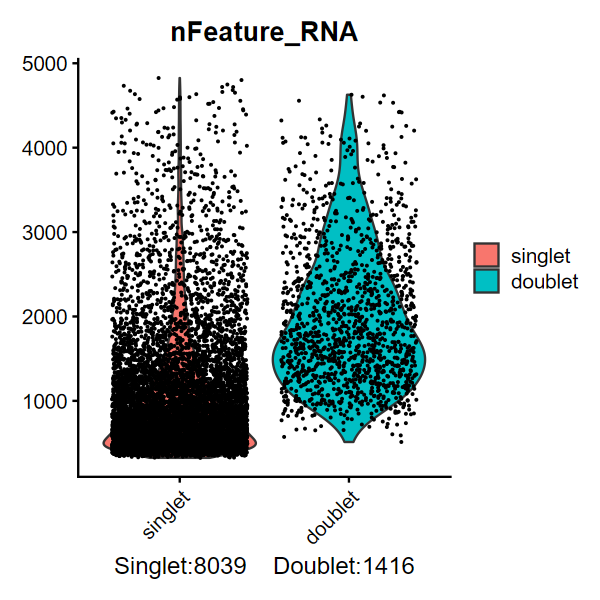

In [7]:
suppressPackageStartupMessages({
    library(scDblFinder)
    library(SingleCellExperiment)
})
sce <- as.SingleCellExperiment(merged_srt)
sce <- suppressMessages(scDblFinder(sce))
merged_srt <- as.Seurat(sce)
merged_srt$ident <- NULL

doublet.count = paste0("Singlet:", length(grep("singlet", merged_srt$scDblFinder.class)), "    ",
                       "Doublet:", length(grep("doublet", merged_srt$scDblFinder.class)))
options(repr.plot.height = 5, repr.plot.width = 5)
VlnPlot(merged_srt, features = "nFeature_RNA", group.by = "scDblFinder.class") & xlab(doublet.count)

In [8]:
merged_srt <- subset(merged_srt, subset = scDblFinder.class  == "singlet")         # Remove doublets

###### **Batch Effect correction**

In [9]:
Elbow_vis <- function(object) {
    pct <- object[["pca"]]@stdev / sum(object[["pca"]]@stdev) * 100      # Determine percent of variation associated with each PC
    cumu <- cumsum(pct)                                                  # Calculate cumulative percents for each PC

    # Determine which PC exhibits cumulative percent greater than 90% and % variation associated with the PC as less than 5
    co1 <- which(cumu > 90 & pct < 5)[1]  
    # Determine the difference between variation of PC and subsequent PC, and last point where change of % of variation is more than 0.1%.
    co2 <- sort(which((pct[1:length(pct) - 1] - pct[2:length(pct)]) > 0.1), decreasing = T)[1] + 1

    pcs <- min(co1, co2)                                                 # Minimum of the two calculation

    plot_df <- data.frame(pct = pct, cumu = cumu, rank = 1:length(pct))  # Create a dataframe with values

    # Elbow plot to visualize 
    ggplot(plot_df, aes(cumu, pct, label = rank, color = rank > pcs)) + geom_text() + geom_vline(xintercept = 90, color = "grey") + 
           geom_hline(yintercept = min(pct[pct > 5]), color = "grey") + theme_bw()
}

In [10]:
merged_srt <- FindVariableFeatures(merged_srt, selection.method = "vst", nfeatures = 2000, verbose = FALSE)
p1 <- LabelPoints(plot = VariableFeaturePlot(merged_srt), points = head(VariableFeatures(merged_srt), 20), xnudge = 0, ynudge = 0, repel = TRUE)

merged_srt <- ScaleData(merged_srt, vars.to.regress = c("nFeature_RNA", "percent_mito", "percent_ribo", "percent_hemo", "CC.Difference"), verbose = FALSE)
merged_srt <- RunPCA(merged_srt, features = VariableFeatures(merged_srt), npcs = 50, verbose = FALSE)
p2 <- Elbow_vis(merged_srt)

options(repr.plot.height = 5, repr.plot.width = 20)
pdf(file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_VF & Elbow.pdf"), height = 5, width = 20, useDingbats=FALSE)
plot_grid(p1, p2, ncol = 2)
dev.off()

png 
  2

In [11]:
merged_srt <- FindNeighbors(merged_srt, dims = 1:16, verbose = FALSE)
merged_srt <- RunUMAP(merged_srt, dims = 1:16, verbose = FALSE)

In [12]:
options(future.globals.maxSize = 8000 * 1024^2)

srtobj_list <- SplitObject(merged_srt, split.by = "orig.ident")
for (i in 1:length(srtobj_list))
    srtobj_list[[i]] <- srtobj_list[[i]] %>% NormalizeData(verbose = FALSE) %>% FindVariableFeatures(selection.method = "vst", nfeatures = 2000, verbose = FALSE)

hvgs_per_dataset <- lapply(srtobj_list, function(x) { x@assays$RNA@var.features })  # get the variable genes from all the datasets.
hvgs_per_dataset$all = VariableFeatures(merged_srt)                                 # add in the variable genes that was selected on the whole dataset
hvgs_all = SelectIntegrationFeatures(srtobj_list)
hvgs_per_dataset$all_ranks = hvgs_all

anchors <- FindIntegrationAnchors(srtobj_list, dims = 1:30, reduction = "cca", anchor.features = hvgs_all, verbose = FALSE)
afterINT <- IntegrateData(anchors, dims = 1:30, new.assay.name = "CCA", verbose = FALSE)

afterINT <- afterINT %>% ScaleData(verbose = FALSE) %>% RunPCA(verbose = FALSE) %>% FindNeighbors(dims = 1:16, verbose = FALSE) %>% RunUMAP(dims = 1:16, verbose = FALSE)
afterINT$orig.ident <- factor(x = afterINT$orig.ident, levels = c(smpl_info$TF0, smpl_info$TF1, smpl_info$TF2))

pdf(file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_BE.pdf"), height = 5, width = 20, useDingbats=FALSE)
plot_grid(DimPlot(merged_srt, group.by="orig.ident") + plot_annotation(title = "Before integration"),
          DimPlot(afterINT, group.by="orig.ident") + plot_annotation(title = "After integration"), ncol = 2)
dev.off()

png 
  2

In [13]:
saveRDS(afterINT, file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_INT.rds"), compress = TRUE)

###### **Clustering**

In [14]:
#rm(list = ls())
srtobj <- readRDS(paste0("./Results/1_scRNAseq/", smpl_info$patient, "_INT.rds"))
#srtobj <- subset(srtobj, orig.ident == smpl_info$TF2)

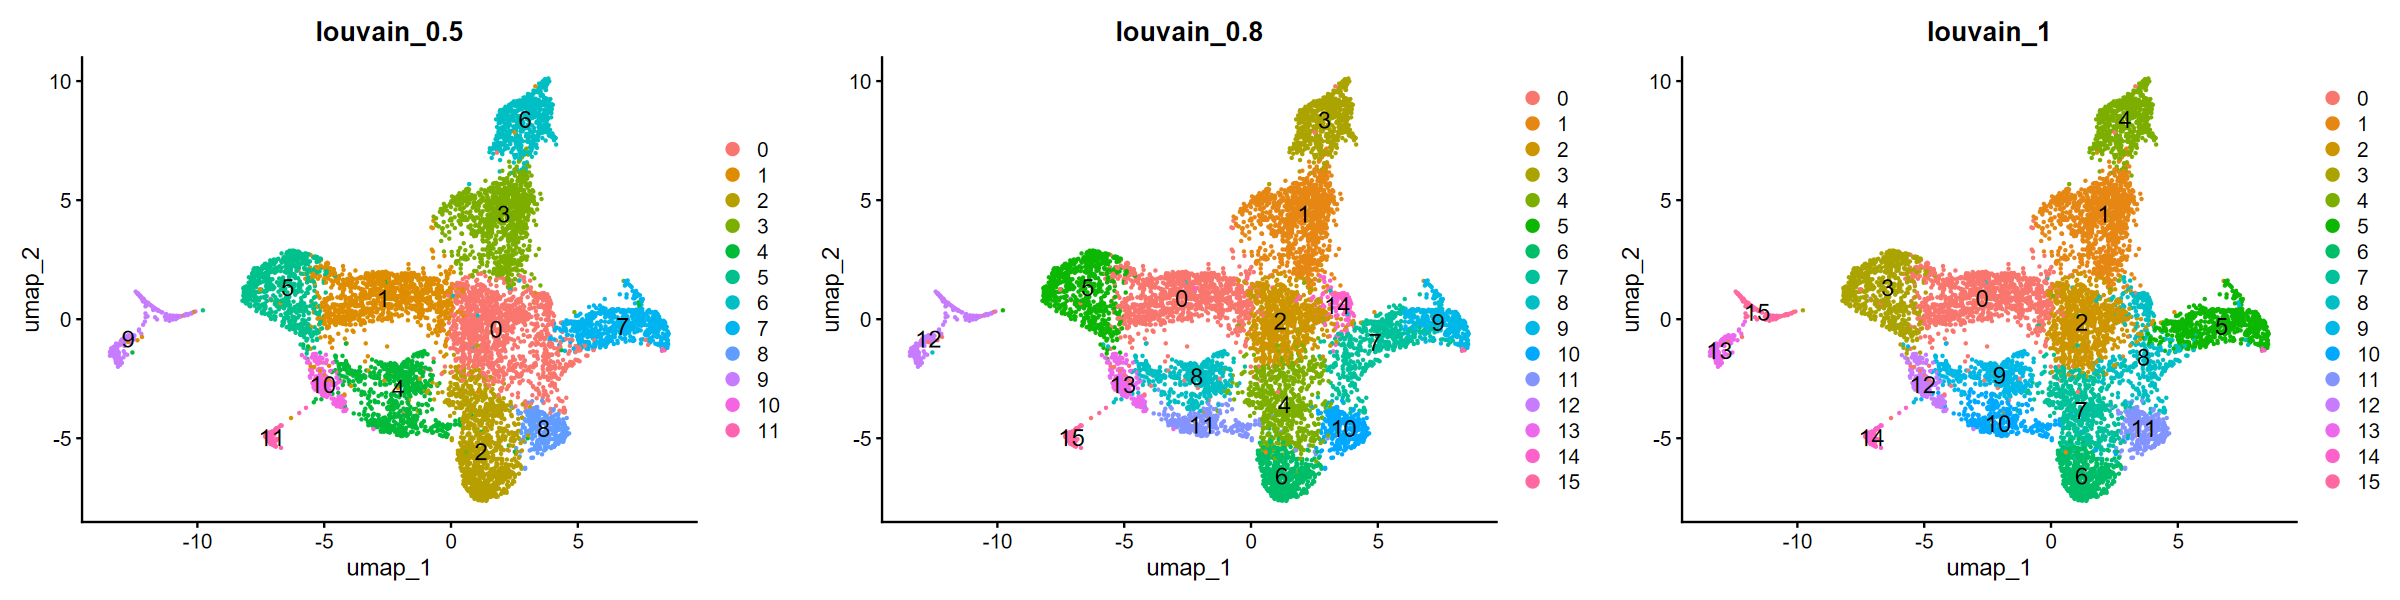

In [15]:
srtobj <- FindClusters(srtobj, resolution = c(0.5, 0.8, 1), verbose = FALSE)

options(repr.plot.height = 5, repr.plot.width = 20)
plot_grid(DimPlot(srtobj, group.by = "CCA_snn_res.0.5", label = TRUE, label.size = 5) + ggtitle("louvain_0.5"), 
          DimPlot(srtobj, group.by = "CCA_snn_res.0.8", label = TRUE, label.size = 5) + ggtitle("louvain_0.8"),
          DimPlot(srtobj, group.by = "CCA_snn_res.1", label = TRUE, label.size = 5) + ggtitle("louvain_1"), ncol = 3)

In [16]:
Idents(srtobj) <- "CCA_snn_res.0.5"
DefaultAssay(srtobj) <- "RNA"
t(table(Idents(srtobj), srtobj$orig.ident))

       
          0   1   2   3   4   5   6   7   8   9  10  11
  Tumor 594 156 311 371 183 108 210 289  90 156  83  33
  2wk   273 253 468 265 142 107 184 107 120  24  21  61
  8wk   477 668 296 394 400 445 260 241 105  57  81   6

###### **DEGs**

In [17]:
DEG_table <- FindAllMarkers(srtobj, assay = "RNA", logfc.threshold = 0.1, only.pos = TRUE, verbose = FALSE)
DEG_table$diff.pct <- DEG_table$pct.1 - DEG_table$pct.2

write.csv(DEG_table, file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_DEGs.csv"), row.names = FALSE, col.names=TRUE)

In [18]:
#top_markers <- as.data.frame(DEG_table %>% group_by(cluster) %>% top_n(-25, p_val_adj))
#top_markers <- as.data.frame(DEG_table %>% group_by(cluster) %>% top_n(25, diff.pct) %>% top_n(50, avg_log2FC) %>% top_n(-100, p_val_adj))
#top_markers <- as.data.frame(DEG_table %>% group_by(cluster) %>% top_n(-25, p_val_adj) %>% filter(avg_log2FC > 1))
top_markers <- as.data.frame(DEG_table %>% group_by(cluster) %>% dplyr::filter(avg_log2FC > 1) %>% slice_head(n = 25) %>% ungroup())

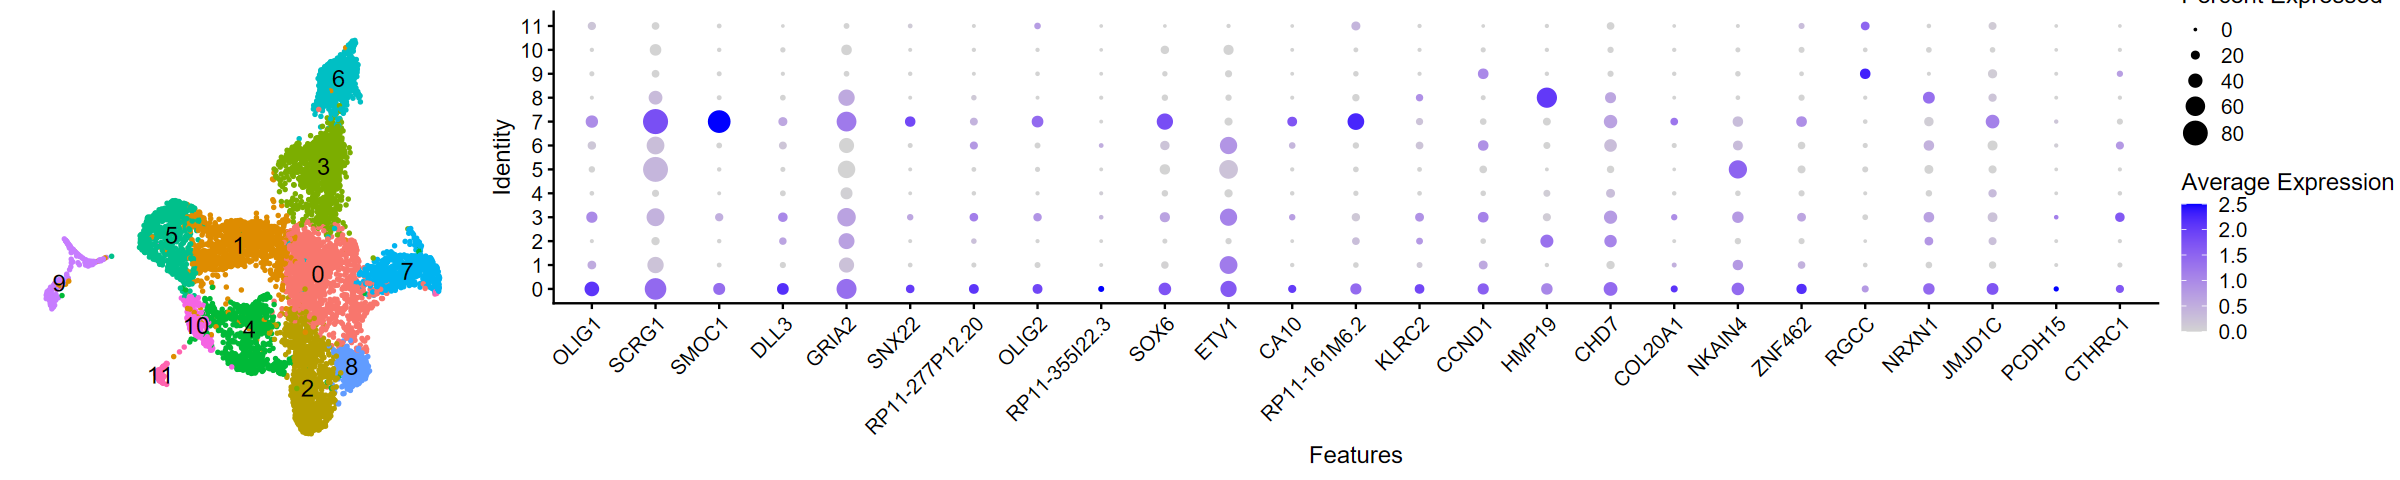

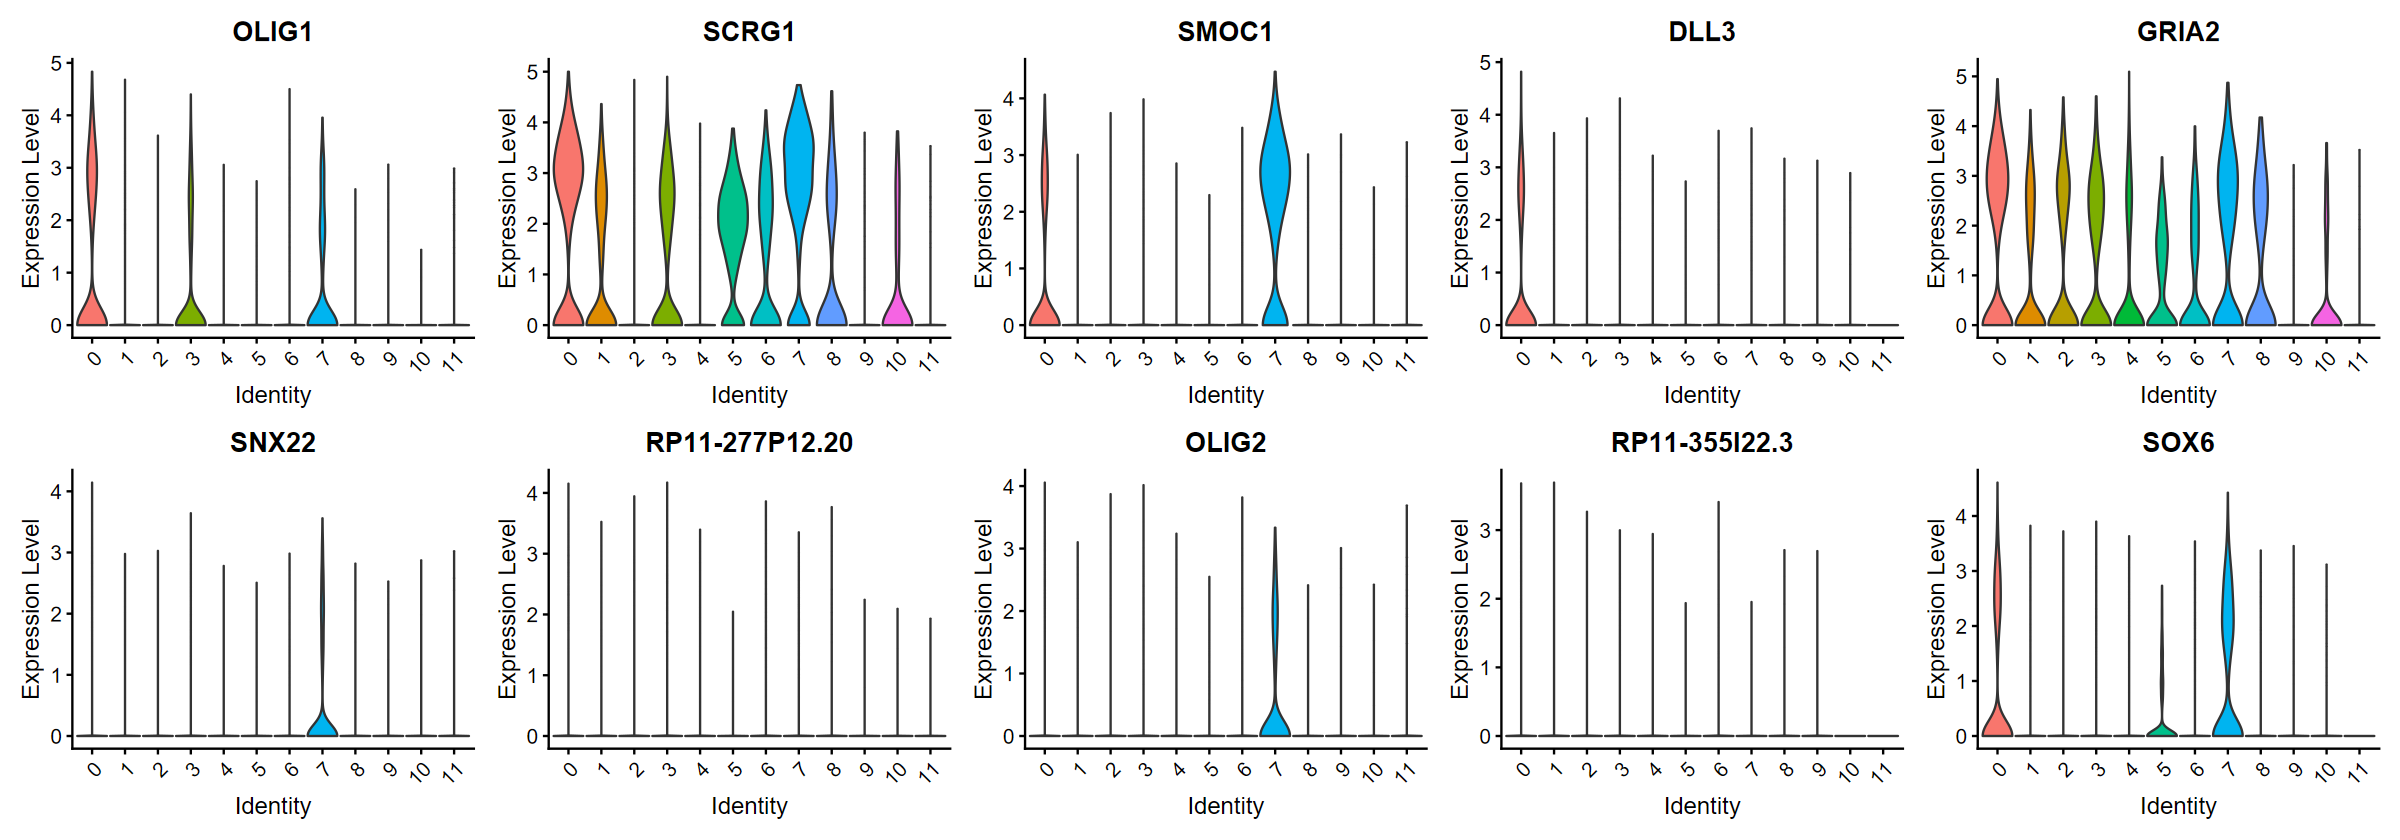

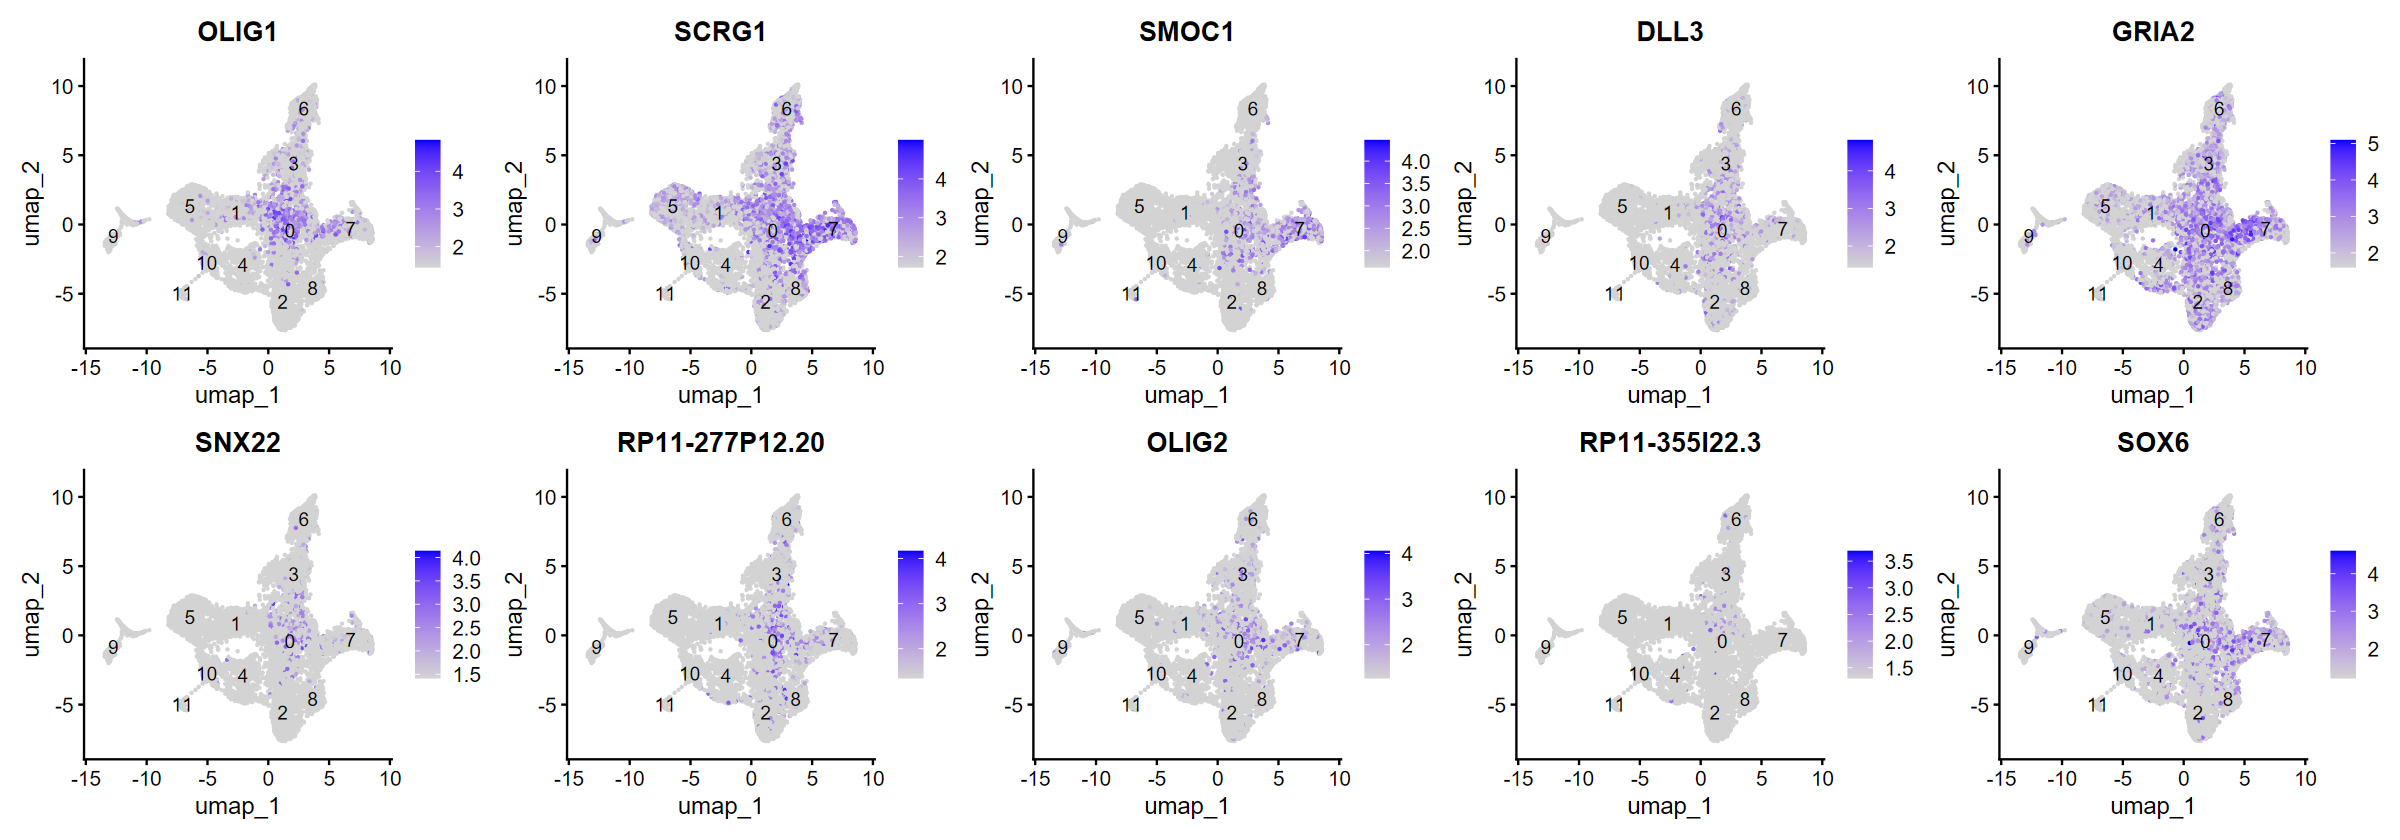

In [19]:
cl = top_markers[which(top_markers$cluster == 0), ]
#feat <- c('LPL', 'TNC', 'PON2', 'PLAT', 'SLC1A3')

options(repr.plot.height = 4, repr.plot.width = 20)
plot_grid(DimPlot(srtobj, pt.size = 0.5, label = TRUE, label.size = 5) & NoLegend() & NoAxes(),
          DotPlot(srtobj, features = cl$gene[1:25], dot.min = 0, col.min = 0) & RotatedAxis(), rel_widths = c(1, 4))

options(repr.plot.height = 7, repr.plot.width = 20)
VlnPlot(srtobj, features = cl$gene[1:10], pt.size = 0, ncol = 5)
FeaturePlot(srtobj, features = cl$gene[1:10], label = TRUE, min.cutoff = "q10", ncol = 5)
#VlnPlot(srtobj, features = feat, pt.size = 0, ncol = 5)
#FeaturePlot(srtobj, features = feat, label = TRUE, min.cutoff = "q10", ncol = 5)

In [20]:
head(top_markers[which(top_markers$cluster == 0), ], 10)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene,diff.pct
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<dbl>
1,1.465667e-145,2.558897,0.414,0.144,3.479201e-141,0,OLIG1,0.270
2,3.146019e-113,1.307315,0.676,0.443,7.468019e-109,0,SCRG1,0.233
3,1.240871e-71,1.441850,0.312,0.122,2.945580e-67,0,SMOC1,0.190
4,1.857532e-71,2.073428,0.303,0.126,4.409410e-67,0,DLL3,0.177
5,1.670661e-68,1.135147,0.617,0.449,3.965814e-64,0,GRIA2,0.168
6,1.551690e-59,2.333800,0.182,0.056,3.683401e-55,0,SNX22,0.126
7,2.830149e-56,2.044071,0.231,0.090,6.718208e-52,0,RP11-277P12.20,0.141
8,4.633287e-55,2.036230,0.232,0.092,1.099850e-50,0,OLIG2,0.140
9,9.766890e-53,3.080678,0.088,0.014,2.318464e-48,0,RP11-355I22.3,0.074


###### **Cell-type identification**

In [ ]:
CellMarkerDB <- data.frame(read_xlsx("./Data/PanglaoDB.xlsx"))
CellMarkerDB <- data.frame(subset(CellMarkerDB, 
                                  species == 'Human' & tissue_class == 'Brain' & cancer_type == 'Glioblastoma', 
                                  select = c('species', 'tissue_class', 'tissue_type', 'cancer_type', 'cell_name', 'marker', 'Symbol','Genetype')))
#head(CellMarkerDB, 5)

In [ ]:
feats = cl$gene[1:30]
gene_marker <- CellMarkerDB[which(CellMarkerDB$marker %in% feats | CellMarkerDB$Symbol %in% feats),]
gene_marker
t(as.data.frame(table(gene_marker$cell_name)))

###### **Celltype annotation**

In [21]:
new.cluster.ids = c('0' = "OPCs",
                    '1' = "Astrocytes",
                    '2' = "Neurons",
                    '3' = "T-regs",
                    '4' = "NK-cells & T-cells",
                    '5' = "Astrocytes",
                    '6' = "T-regs",
                    '7' = "OPCs",
                    '8' = "Neurons",
                    '9' = "Macrophages/Microglia cells",
                    '10'= "Epithelial cells",                  
                    '11'= "Oligodendrocytes")
names(new.cluster.ids) = levels(srtobj)
srtobj = RenameIdents(srtobj, new.cluster.ids)
srtobj$cell_types <- as.character(srtobj@active.ident)

saveRDS(srtobj, file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_Final.rds"), compress = TRUE)

pdf(file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_Final.pdf"), width = 10, height = 10, onefile = TRUE)
DimPlot(srtobj, label = TRUE, label.size = 4, repel = TRUE)
dev.off()

png 
  2

In [22]:
library(RColorBrewer)

pt <- as.data.frame(table(Idents(srtobj), srtobj$orig.ident))
pt$Var1 <- as.character(pt$Var1)
pt$Var2 <- factor(x = pt$Var2, levels = c(smpl_info$TF0, smpl_info$TF1, smpl_info$TF2))
pt <- pt %>% group_by(Var2) %>% mutate(percent = round(Freq / sum(Freq), 2))

options(repr.plot.height = 5, repr.plot.width = 20)
pdf(file = paste0("./Results/1_scRNAseq/", smpl_info$patient, "_ctPCT.pdf"), width = 20, height = 5, onefile = TRUE)
ggplot(pt, aes(x = Var2, y = Freq, fill = Var1)) + coord_flip() + theme_bw(base_size = 15) + geom_col(position = "fill", width = 0.5) +
           geom_text(aes(label = scales::percent(percent)), size = 5, position = position_fill(vjust = 0.5), angle = 90) +
           xlab("Time frames") + ylab("Proportion") + scale_fill_manual(values = brewer.pal(12, "Paired")) + theme(legend.title = element_blank())
dev.off()

png 
  2

### *Step 2 : Analysis of spatial datasets*

###### **Preprocessing, QC**

In [3]:
spatial_data = Load10X_Spatial("./Data/HumanGBM_10Xgenomics/",
                             "filtered_feature_bc_matrix.h5", assay = "Spatial", slice = "image", filter.matrix = TRUE)
spatial_data@meta.data$barcode <- row.names(spatial_data@meta.data)
spatial_data@meta.data <- spatial_data@meta.data[, c("orig.ident", "barcode", "nCount_Spatial", "nFeature_Spatial")]

In [4]:
spatial_data[['percent_mito']] <- PercentageFeatureSet(spatial_data, pattern = '^MT-')
spatial_data[['percent_ribo']] <- PercentageFeatureSet(spatial_data, pattern = '^RP[SL]')
spatial_data[['percent_hemo']] <- PercentageFeatureSet(spatial_data, pattern = '^HB[^(P)]')

options(repr.plot.height = 5, repr.plot.width = 20)
feats <- c("nFeature_Spatial", "nCount_Spatial", "percent_mito", "percent_ribo", "percent_hemo")
pdf(file = paste0("./Results/2_stRNAseq/Human_Glioblastoma_Whole_QC.pdf"), height = 5, width = 20, useDingbats=FALSE)
VlnPlot(spatial_data, features = feats, group.by = "orig.ident", pt.size = 0.1, ncol = 5) & theme(axis.title.x = element_blank())
plot_grid(FeatureScatter(spatial_data, "nCount_Spatial", "nFeature_Spatial", group.by = "orig.ident") + NoLegend(),
          FeatureScatter(spatial_data, "nCount_Spatial", "percent_mito", group.by = "orig.ident") + NoLegend(), ncol = 2)

spatial_data <- spatial_data[!grepl("MALAT1", rownames(spatial_data)), ]        # Filter MALAT1
spatial_data <- spatial_data[!grepl("^MT-", rownames(spatial_data)), ]          # Filter Mitocondrial genes
spatial_data <- spatial_data[!grepl("^RP[SL]", rownames(spatial_data)), ]       # Filter Ribossomal genes
spatial_data <- spatial_data[!grepl("^HB[^(P)]", rownames(spatial_data)), ]     # Filter Hemoglobin genes
spatial_data <- subset(spatial_data, subset = nFeature_Spatial < 8000 & nFeature_Spatial > 500 & nCount_Spatial < 35000 & percent_mito < 15 & percent_ribo < 20 & percent_hemo < 0.3)

VlnPlot(spatial_data, features = feats, group.by = "orig.ident", pt.size = 0.1, ncol = 5) & theme(axis.title.x = element_blank())
plot_grid(FeatureScatter(spatial_data, "nCount_Spatial", "nFeature_Spatial", group.by = "orig.ident") + NoLegend(),
          FeatureScatter(spatial_data, "nCount_Spatial", "percent_mito", group.by = "orig.ident") + NoLegend(), ncol = 2)
dev.off()

png 
  2

###### **Dimensionality reduction, Clustering**

In [5]:
spatial_data <- spatial_data %>% SCTransform(assay = "Spatial", vst.flavor = "v1", verbose = FALSE) %>%
                                 RunPCA(assay = "SCT", verbose = FALSE) %>% 
                                 FindNeighbors(dims = 1:30, verbose = FALSE) %>%
                                 FindClusters(verbose = FALSE) %>%
                                 RunUMAP(dims = 1:30, verbose = FALSE)

pdf(file = paste0("./Results/2_stRNAseq/Human_Glioblastoma_Whole_Clustered.pdf"), height = 5, width = 20, useDingbats=FALSE)
plot_grid(DimPlot(spatial_data, reduction = "umap", label = TRUE, label.size = 6, pt.size = 1),
          SpatialDimPlot(spatial_data, label = TRUE, label.size = 6, pt.size = 2) + NoLegend())
dev.off()
#SpatialDimPlot(stData, cells.highlight = CellsByIdentities(stData, idents = c(2, 1, 4, 3, 5, 8)), facet.highlight = TRUE, ncol = 6)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


png 
  2

###### **Identification of Spatially Variable Features (SVF)**

In [6]:
SpatiallyVariableFeatures_workaround <- function(object, assay="SCT", selection.method = "moransi") {
    #' This is work around function to replace SeuratObject::SpatiallyVariableFeatures function.
    #' return ranked list of Spatially Variable Features
    
    # Check if object is a Seurat object
    if (!inherits(object, "Seurat")) {
        stop("object must be a Seurat object")
    }
    
    # Check if assay is a valid assay
    if (!assay %in% names(object@assays)) {
        stop("assay must be a valid assay")
    }
    
    # Extract meta.features from the specified object and assay
    data <- object@assays[[assay]]@meta.features
    
    # Select columns starting with the provided col_prefix
    moransi_cols <- grep(paste0("^", selection.method), colnames(data), value = TRUE)
    
    # Filter rows where "moransi.spatially.variable" is TRUE
    filtered_data <- data[data[[paste0(selection.method, ".spatially.variable")]], moransi_cols]
    
    # Sort filtered data by "moransi.spatially.variable.rank" column in ascending order
    sorted_data <- filtered_data[order(filtered_data[[paste0(selection.method, ".spatially.variable.rank")]]), ]
    
    # Return row names of the sorted data frame
    rownames(sorted_data)
}

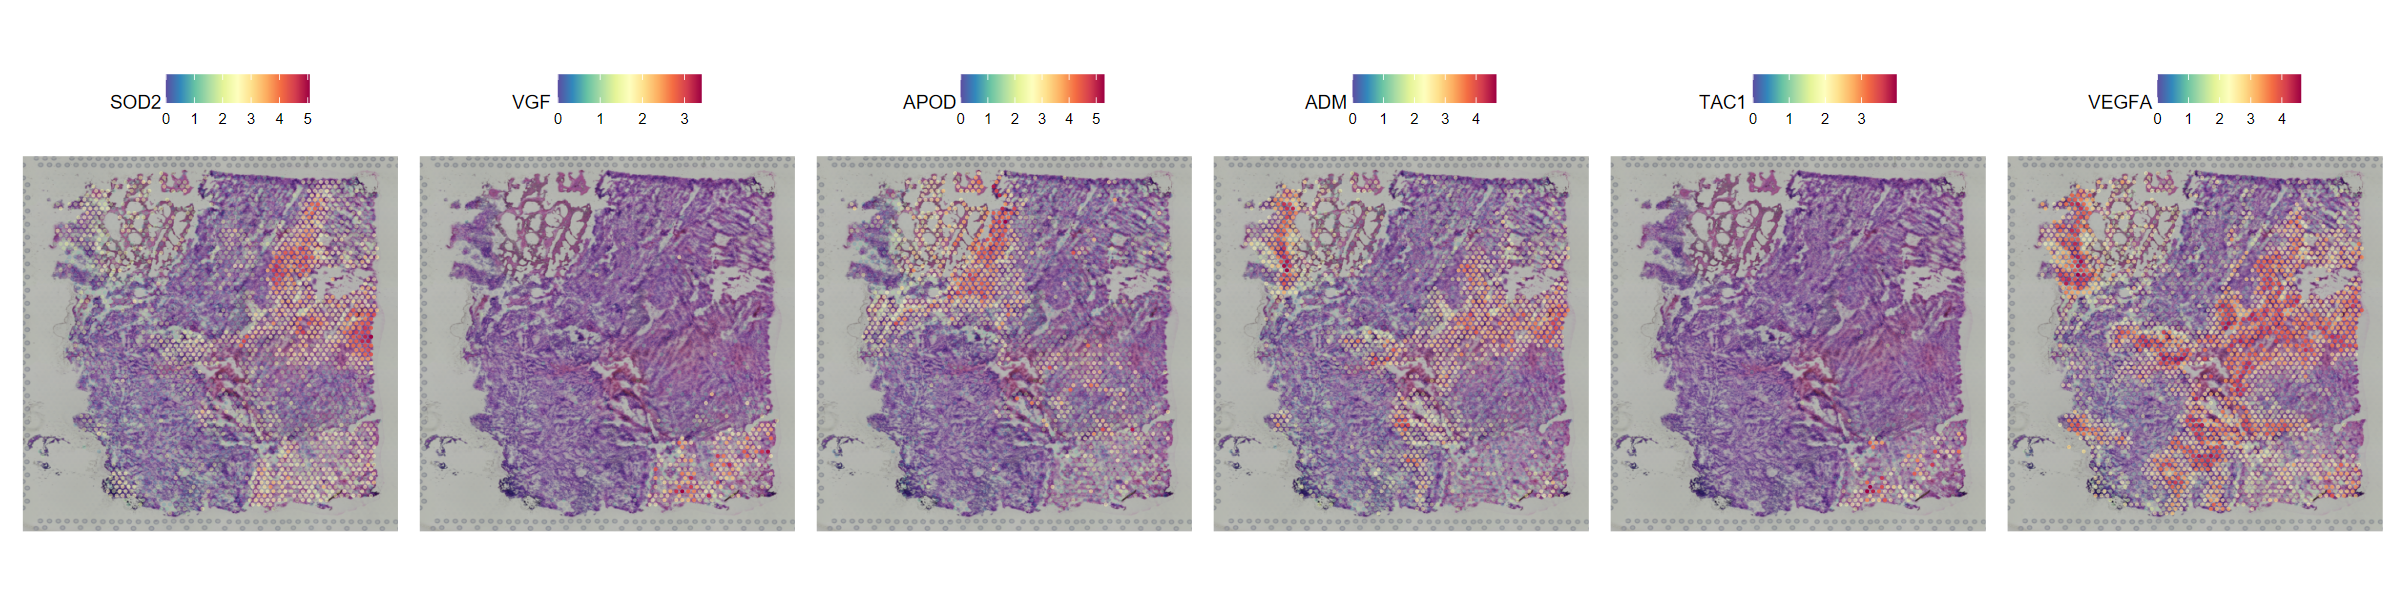

In [7]:
spatial_data <- FindSpatiallyVariableFeatures(spatial_data, assay = 'SCT', 
                                              features = VariableFeatures(spatial_data)[1:25], selection.method = 'moransi', verbose = FALSE)
top.features <- head(SpatiallyVariableFeatures_workaround(spatial_data, selection.method = 'moransi'), 6)
SpatialPlot(spatial_data, features = top.features, ncol = 6, alpha = c(0.1, 1))

In [8]:
saveRDS(spatial_data, file = paste0("./Results/2_stRNAseq/Human_Glioblastoma_Whole_SVF.rds"), compress = TRUE)

###### **DEGs**

In [ ]:
DEG_table <- FindAllMarkers(spatial_data, logfc.threshold = 0.1, only.pos = TRUE, verbose = FALSE)
DEG_table$diff.pct <- DEG_table$pct.1 - DEG_table$pct.2

In [ ]:
#top_markers <- as.data.frame(DEG_table %>% group_by(cluster) %>% top_n(-25, p_val_adj))
#top_markers <- as.data.frame(DEG_table %>% group_by(cluster) %>% top_n(25, diff.pct) %>% top_n(50, avg_log2FC) %>% top_n(-100, p_val_adj))
#top_markers <- as.data.frame(DEG_table %>% group_by(cluster) %>% top_n(-25, p_val_adj) %>% filter(avg_log2FC > 1))
top_markers <- as.data.frame(DEG_table %>% group_by(cluster) %>% dplyr::filter(avg_log2FC > 1) %>% slice_head(n = 25) %>% ungroup())

In [ ]:
cl = top_markers[which(top_markers$cluster == 15), ]
feat <- c('LPL', 'TNC', 'PON2', 'PLAT', 'SLC1A3')

options(repr.plot.height = 4, repr.plot.width = 20)
plot_grid(DimPlot(spatial_data, pt.size = 0.5, label = TRUE, label.size = 5) & NoLegend() & NoAxes(),
          DotPlot(spatial_data, features = cl$gene, dot.min = 0, col.min = 0) & RotatedAxis(), rel_widths = c(1, 4))

options(repr.plot.height = 7, repr.plot.width = 20)
VlnPlot(spatial_data, features = cl$gene[1:10], pt.size = 0, ncol = 5)
FeaturePlot(spatial_data, features = cl$gene[1:10], label = TRUE, min.cutoff = "q10", ncol = 5)
#VlnPlot(spatial_data, features = feat, pt.size = 0, ncol = 5)
#FeaturePlot(spatial_data, features = feat, label = TRUE, min.cutoff = "q10", ncol = 5)

In [ ]:
head(top_markers[which(top_markers$cluster == 15), ], 10)

In [ ]:
new.cluster.ids = c('0' = "Neurons",
                    '1' = "Endothelial cells", 
                    '2' = "Microglial cells", 
                    '3' = "Epithelial cells",
                    '4' = "Oligodendrocytes", 
                    '5' = "Astrocytes", 
                    '6' = "Neurons", 
                    '7' = "Neurons",
                    '8' = "Epithelial cells",
                    '9' = "Oligodendrocyte precursor cells",
                    '10'= "Fibroblasts")
names(new.cluster.ids) = levels(spatial_data)
spatial_data = RenameIdents(spatial_data, new.cluster.ids)
spatial_data$cell_types <- as.character(spatial_data@active.ident)

saveRDS(spatial_data, file = paste0("./Results/2_stRNAseq/Human_Glioblastoma_Whole_SVF.rds"), compress = TRUE)

pdf(file = paste0("./Results/2_stRNAseq/Human_Glioblastoma_Whole_SVF.pdf"), height = 5, width = 20, useDingbats=FALSE)
plot_grid(DimPlot(spatial_data, reduction = "umap", repel = TRUE, label = TRUE, label.size = 5),
          SpatialDimPlot(spatial_data, repel = TRUE, label = TRUE, label.size = 5))
dev.off()

### *Step 3 : Spatial transcriptomics deconvolution at Single-cell resolution*

###### **Loading of Single-cell and Spatial datasets**

In [3]:
smpl <- paste0(smpl_info$patient,'_', smpl_info$TF0)

reference <- readRDS("./Results/1_scRNAseq/8036_Final.rds")                            # integrated scRNA data
reference <- reference[, reference$orig.ident == unlist(strsplit(smpl, '_'))[2]]       # Select single sample of "reference"

query <- readRDS("./Results/2_stRNAseq/Human_Glioblastoma_Whole_SVF.rds")              # spatial data

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


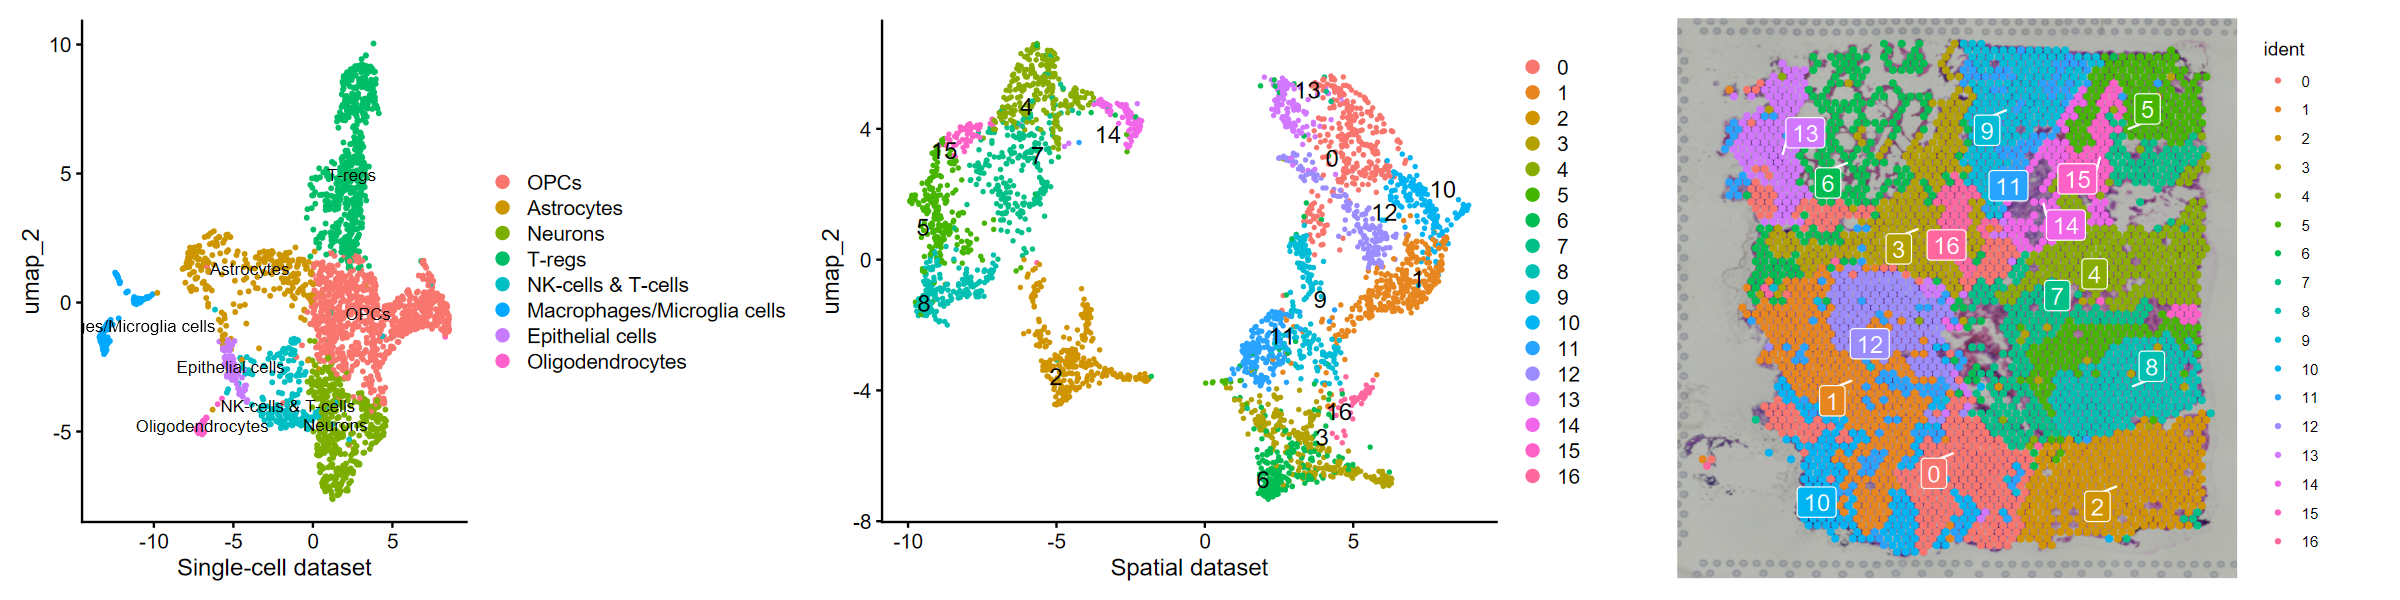

In [4]:
options(repr.plot.height = 5, repr.plot.width = 20)
#pdf(file = paste0("./Results/3_deconvolution/", smpl, "_plots.pdf"), height = 5, width = 20, useDingbats=FALSE)
plot_grid(DimPlot(reference, label = TRUE, label.size = 3.5) & xlab("Single-cell dataset"),
          DimPlot(query, label = TRUE, label.size = 5, repel = TRUE) & xlab("Spatial dataset"),
          SpatialDimPlot(query, label = TRUE, label.size = 5, pt.size.factor = 2.5, repel = TRUE), ncol = 3)
#dev.off()

###### **Cell Type Deconvolution(CARD)**

In [5]:
###### **Preparing required input data**

spatial_count <- query[["Spatial"]]$counts
spatial_location <- GetTissueCoordinates(query)
colnames(spatial_count) <- gsub(" ", "x", paste(spatial_location$x, spatial_location$y))
rownames(spatial_location) <- gsub(" ", "x", paste(spatial_location$x, spatial_location$y))
spatial_location$cell <- NULL

sc_count <- reference[["RNA"]]$counts
sc_meta <- reference@meta.data[, c('barcode', 'patient', 'orig.ident', 'cell_types')]
sc_meta$cellID <- rownames(sc_meta)
sc_meta <- sc_meta[, c('cellID', 'barcode', 'patient', 'orig.ident', 'cell_types')]
colnames(sc_meta) <- c('cellID', 'barcode', 'patient', 'sampleInfo', 'cellType')

In [6]:
suppressPackageStartupMessages({
    library(CARD)
    library(SingleCellExperiment)
})
CARD_obj = createCARDObject(sc_count, sc_meta, spatial_count, spatial_location, ct.varname = "cellType", 
                            ct.select = unique(sc_meta$cellType), sample.varname = "sampleInfo", minCountGene = 100, minCountSpot = 5) 
CARD_obj = suppressMessages(CARD_deconvolution(CARD_obj))

## QC on scRNASeq dataset! ...
## QC on spatially-resolved dataset! ...
## create reference matrix from scRNASeq...
## Select Informative Genes! ...
## Deconvolution Starts! ...
## Deconvolution Finish! ...


In [7]:
## visualize the spatial distribution of the cell type proportion at a standard resolution
p1 <- CARD.visualize.prop(CARD_obj@Proportion_CARD, CARD_obj@spatial_location, sort(colnames(CARD_obj@Proportion_CARD)), NumCols = 10, pointSize = 0.5)

## visualize the spatial distribution of the cell type proportion at an enhanced resolution
CARD_obj = CARD.imputation(CARD_obj, NumGrids = 4000, ineibor = 10, exclude = NULL)
location_imputation = cbind.data.frame(x=as.numeric(sapply(strsplit(rownames(CARD_obj@refined_prop), split="x"),"[",1)),
                                       y=as.numeric(sapply(strsplit(rownames(CARD_obj@refined_prop), split="x"),"[",2)))
rownames(location_imputation) = rownames(CARD_obj@refined_prop)
p2 <- CARD.visualize.prop(CARD_obj@refined_prop, location_imputation, sort(colnames(CARD_obj@refined_prop)), NumCols = 10, pointSize = 0.5)

saveRDS(CARD_obj, file = paste0("./Results/3_deconvolution/", smpl, ".rds"), compress = TRUE)

pdf(file = paste0("./Results/3_deconvolution/", smpl, "_decon.pdf"), height = 5, width = 20, useDingbats=FALSE)
plot_grid(p1 , p2, labels = c('Unrefined', 'Refined'), nrow = 2)
CARD.visualize.Cor(CARD_obj@Proportion_CARD, colors = NULL) 

dev.off()

## The rownames of locations are matched ...
## Make grids on new spatial locations ...


png 
  2

###### **Cell Type Deconvolution(RCTD)**

In [ ]:
library(spacexr)

# create the RCTD reference object
Idents(reference) <- "cell_types"
counts <- reference[["RNA"]]$counts
cluster <- as.factor(reference$cell_types)
nUMI <- reference$nCount_RNA
levels(cluster) <- gsub("/", "-", levels(cluster))
cluster <- droplevels(cluster)
scRNA <- Reference(counts, cluster, nUMI)

# create the RCTD query object
counts_hd <- query[["Spatial"]]$counts
cortex_cells_hd <- colnames(query[["Spatial"]])
coords <- GetTissueCoordinates(query)[cortex_cells_hd, 1:2]
stRNA <- SpatialRNA(coords, counts_hd, colSums(counts_hd))

In [ ]:
myRCTD <- create.RCTD(stRNA, scRNA, max_cores = 8)
myRCTD <- suppressMessages(run.RCTD(myRCTD, doublet_mode = 'doublet'))
query  <- AddMetaData(query, metadata = myRCTD@results$results_df)

In [ ]:
barcodes <- colnames(myRCTD@spatialRNA@counts)
cell_type_names <- myRCTD@cell_type_info$info[[2]] 
norm_weights <- normalize_weights(myRCTD@results$weights)

options(repr.plot.height = 5, repr.plot.width = 20)
plot_cond_occur(cell_type_names, './Results/', norm_weights, myRCTD@spatialRNA)
plot_weights_unthreshold(cell_type_names, myRCTD@spatialRNA, './Results/', norm_weights) 

### *Step 4 : Learning-based Modeling of Tumor Cell Migration*

###### **Data Loading, Extracting of cell location based on the cell types**

In [3]:
suppressPackageStartupMessages({
    library(CARD)
    library(SingleCellExperiment)
})

In [ ]:
CARDobj_0 <- readRDS(paste0('./3_deconvolution/', smpl_info$patient, '_', smpl_info$TF0,'.rds'))
CARDobj_1 <- readRDS(paste0('./3_deconvolution/', smpl_info$patient, '_', smpl_info$TF1,'.rds'))
CARDobj_2 <- readRDS(paste0('./3_deconvolution/', smpl_info$patient, '_', smpl_info$TF2,'.rds'))

In [ ]:
scMapping_0 <- CARD_SCMapping(CARDobj_0, shapeSpot = "Circle", numCell = 20, ncore = 1)
scMapping_1 <- CARD_SCMapping(CARDobj_1, shapeSpot = "Circle", numCell = 20, ncore = 1)
scMapping_2 <- CARD_SCMapping(CARDobj_2, shapeSpot = "Circle", numCell = 20, ncore = 1)

In [ ]:
MapCellCords_0 = as.data.frame(colData(scMapping_0))
count_SC_0 = assays(scMapping_0)$counts

MapCellCords_1 = as.data.frame(colData(scMapping_1))
count_SC_1 = assays(scMapping_1)$counts

MapCellCords_2 = as.data.frame(colData(scMapping_2))
count_SC_2 = assays(scMapping_2)$counts

CellLoc <- data.frame(x = MapCellCords_0$x, y = MapCellCords_0$y, centerSPOT = MapCellCords_0$centerSPOT, centerx = MapCellCords_0$centerx, centery = MapCellCords_0$centery)
CellLoc$TF0 <- 0; CellLoc$TF0_ct <- MapCellCords_0$CT
CellLoc$TF1 <- 1; CellLoc$TF1_ct <- MapCellCords_1$CT
CellLoc$TF2 <- 2; CellLoc$TF2_ct <- MapCellCords_2$CT

write.csv(CellLoc, file = paste0("./Results/4_modelling/", smpl_info$patient, "_CellLoc.csv"), row.names = FALSE, col.names=TRUE)

###### **Statistical analyses**

In [3]:
stats_df <- read.csv(paste0('../Results - GBM/4_modelling/', smpl_info$patient, '_CellLoc.csv'))

In [4]:
head(stats_df)

,x,y,centerSPOT,centerx,centery,TF0,TF0_ct,TF1,TF1_ct,TF2,TF2_ct
,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<chr>,<int>,<chr>,<int>,<chr>
1,7436.297,9386.806,7438x9389,7438,9389,0,Astrocytes,1,Astrocytes,2,Astrocytes
2,7436.489,9385.264,7438x9389,7438,9389,0,Macrophages/Microglia cells,1,Astrocytes,2,Astrocytes
3,7450.209,9382.174,7438x9389,7438,9389,0,Macrophages/Microglia cells,1,Astrocytes,2,Astrocytes
4,7432.905,9405.239,7438x9389,7438,9389,0,Astrocytes,1,Astrocytes,2,Astrocytes
5,7456.794,9378.448,7438x9389,7438,9389,0,Astrocytes,1,Astrocytes,2,Astrocytes
6,7463.905,9389.720,7438x9389,7438,9389,0,Astrocytes,1,Astrocytes,2,Astrocytes


In [6]:
stats_df$RowID <- seq_len(nrow(stats_df))
stats_df$dist_to_centerSPOT <- sqrt((stats_df$x - stats_df$centerx)^2 + (stats_df$y - stats_df$centery)^2)
stats_df <-  stats_df[, c(12, 1:5, 13, 6:11)]

tf01 <- data.frame(RowID = stats_df$RowID, interval = "TF0→TF1", from_time = 0, to_time = 1, 
                   from_ct = stats_df$TF0_ct, to_ct = stats_df$TF1_ct, changed = stats_df$TF0_ct != stats_df$TF1_ct, stringsAsFactors = FALSE)

tf12 <- data.frame(RowID = stats_df$RowID, interval = "TF1→TF2", from_time = 1, to_time = 2,
                   from_ct = stats_df$TF1_ct, to_ct = stats_df$TF2_ct, changed = stats_df$TF1_ct != stats_df$TF2_ct, stringsAsFactors = FALSE)

transitions <- rbind(tf01, tf12)
names(transitions)[names(transitions) == "from_ct"] <- "baseline_ct"

In [7]:
split_key <- interaction(transitions$baseline_ct, transitions$interval, drop = TRUE)

summary_list <- lapply(split(transitions, split_key), function(d) {
    data.frame(
        baseline_ct   = d$baseline_ct[1],
        interval      = d$interval[1],
        N             = nrow(d),
        n_changed     = sum(d$changed, na.rm = TRUE),
        prop_changed  = mean(d$changed, na.rm = TRUE),
        stringsAsFactors = FALSE
    )
})
summary_by_ct <- do.call(rbind, summary_list)

summary_overall <- do.call(rbind, lapply(split(transitions, transitions$interval), function(d){
    data.frame(
        baseline_ct   = "__ALL__",
        interval      = d$interval[1],
        N             = nrow(d),
        n_changed     = sum(d$changed, na.rm = TRUE),
        prop_changed  = mean(d$changed, na.rm = TRUE),
        stringsAsFactors = FALSE
    )
}))

diff_sum <- rbind(summary_by_ct, summary_overall)

In [8]:
transitions$baseline_ct <- as.factor(transitions$baseline_ct)
transitions$interval <- as.factor(transitions$interval)
transitions$changed <- as.logical(transitions$changed)

# For each cell type: build contingency table (interval × changed)
diff_stats <- transitions %>% group_by(baseline_ct) %>% group_modify(~ {
    tab <- table(.x$interval, .x$changed)
    if (all(dim(tab) == c(2,2))) {
        p_chisq  <- suppressWarnings(chisq.test(tab)$p.value)
        p_fisher <- fisher.test(tab)$p.value
        data.frame(method = c("Chi-sq","Fisher"), p_value = c(p_chisq, p_fisher))
    } else {
        data.frame(method = "NA", p_value = NA_real_)
    }
})

# Adjust p-values (FDR) separately for each method
diff_stats <- diff_stats %>% group_by(method) %>% mutate(p_adj = p.adjust(p_value, method = "fdr")) %>% ungroup()

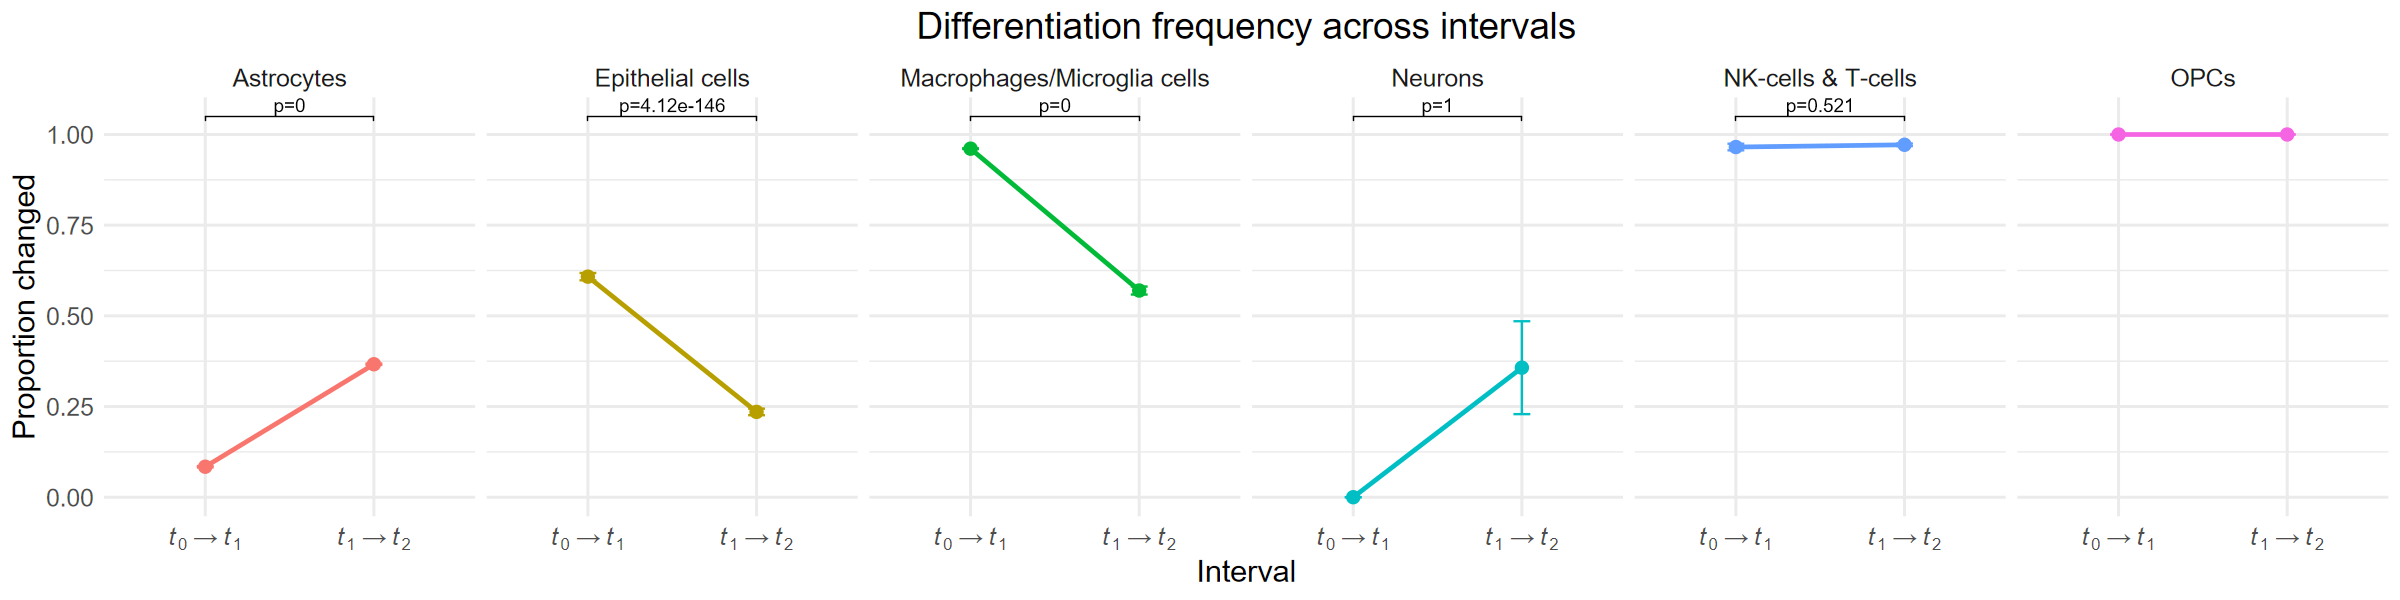

In [13]:
# Summarize proportion changed per baseline_ct × interval
summary_plot <- transitions %>% group_by(baseline_ct, interval) %>% summarise(prop_changed = mean(changed, na.rm = TRUE),
                                                                              N = n(),
                                                                              se = sqrt(prop_changed * (1 - prop_changed) / N), .groups = "drop")

# Prepare p-value annotations (use Fisher’s test results by default)
pvals <- diff_stats %>% filter(method == "Fisher" & !is.na(p_value)) %>% mutate(group1 = "TF0→TF1",
                                                                                group2 = "TF1→TF2",
                                                                                y.position = max(summary_plot$prop_changed) + 0.05,
                                                                                label = paste0("p=", signif(p_value, 3)))

options(repr.plot.height = 5, repr.plot.width = 20)
p <- ggplot(summary_plot, aes(x = interval, y = prop_changed, group = baseline_ct, color = baseline_ct)) +
            geom_point(size = 3) + geom_line(size = 1) + geom_errorbar(aes(ymin = prop_changed - se, ymax = prop_changed + se), width = 0.1) +
            facet_wrap(~ baseline_ct, nrow = 1) + theme_minimal(base_size = 14) + labs(title = "Differentiation frequency across intervals",
                                                                                       y = "Proportion changed", x = "Interval") + 
                                                                                       scale_x_discrete(labels = c("TF0→TF1" = expression(italic(t)[0] %->% italic(t)[1]),
                                                                                                                   "TF1→TF2" = expression(italic(t)[1] %->% italic(t)[2]))) +
                                                                                       theme(plot.title = element_text(hjust = 0.5),
                                                                                             text = element_text(size = 18),
                                                                                             legend.position = "none")

# Add statistical annotations (optional: only if you want visible p-values)
if (nrow(pvals) > 0) {
    p <- p + stat_pvalue_manual(pvals, label = "label", tip.length = 0.01, hide.ns = TRUE)
}

p
ggsave("../Results - GBM/4_modelling/diff_plot.tiff", p, width = 15, height = 5, dpi = 350, compression = "lzw")

In [14]:
# Distance to center per cell (same across time points)
stats_df$dist_to_centerSPOT <- sqrt((stats_df$x - stats_df$centerx)^2 + (stats_df$y - stats_df$centery)^2)

# Build migration dataframe
# Since x,y don't change over TFs, migration here is modeled as difference between cell type centroids
# Example: if a cell changes type, we record its distance as "migrated", else 0
mig_tf01 <- data.frame(RowID = seq_len(nrow(stats_df)), interval = "TF0→TF1", 
                       baseline_ct = stats_df$TF0_ct, changed = stats_df$TF0_ct != stats_df$TF1_ct, dist = stats_df$dist_to_centerSPOT)
mig_tf12 <- data.frame(RowID = seq_len(nrow(stats_df)), interval = "TF1→TF2", 
                       baseline_ct = stats_df$TF1_ct, changed = stats_df$TF1_ct != stats_df$TF2_ct, dist = stats_df$dist_to_centerSPOT)

mig_df <- rbind(mig_tf01, mig_tf12)

# Summary statistics
mig_sum <- mig_df %>% group_by(baseline_ct, interval) %>% summarise(mean_dist = mean(dist, na.rm = TRUE),
                                                                    sd_dist = sd(dist, na.rm = TRUE), .groups = "drop")

# Statistical test (ANOVA across intervals for each cell type)
mig_stats <- mig_df %>% group_by(baseline_ct) %>% group_modify(~ {
    aov_res <- aov(dist ~ interval, data = .x)
    data.frame(p_value = summary(aov_res)[[1]][["Pr(>F)"]][1])
})

mig_stats$p_adj <- p.adjust(mig_stats$p_value, method = "fdr")
mig_df$baseline_ct <- as.factor(mig_df$baseline_ct)
mig_df$interval <- as.factor(mig_df$interval)

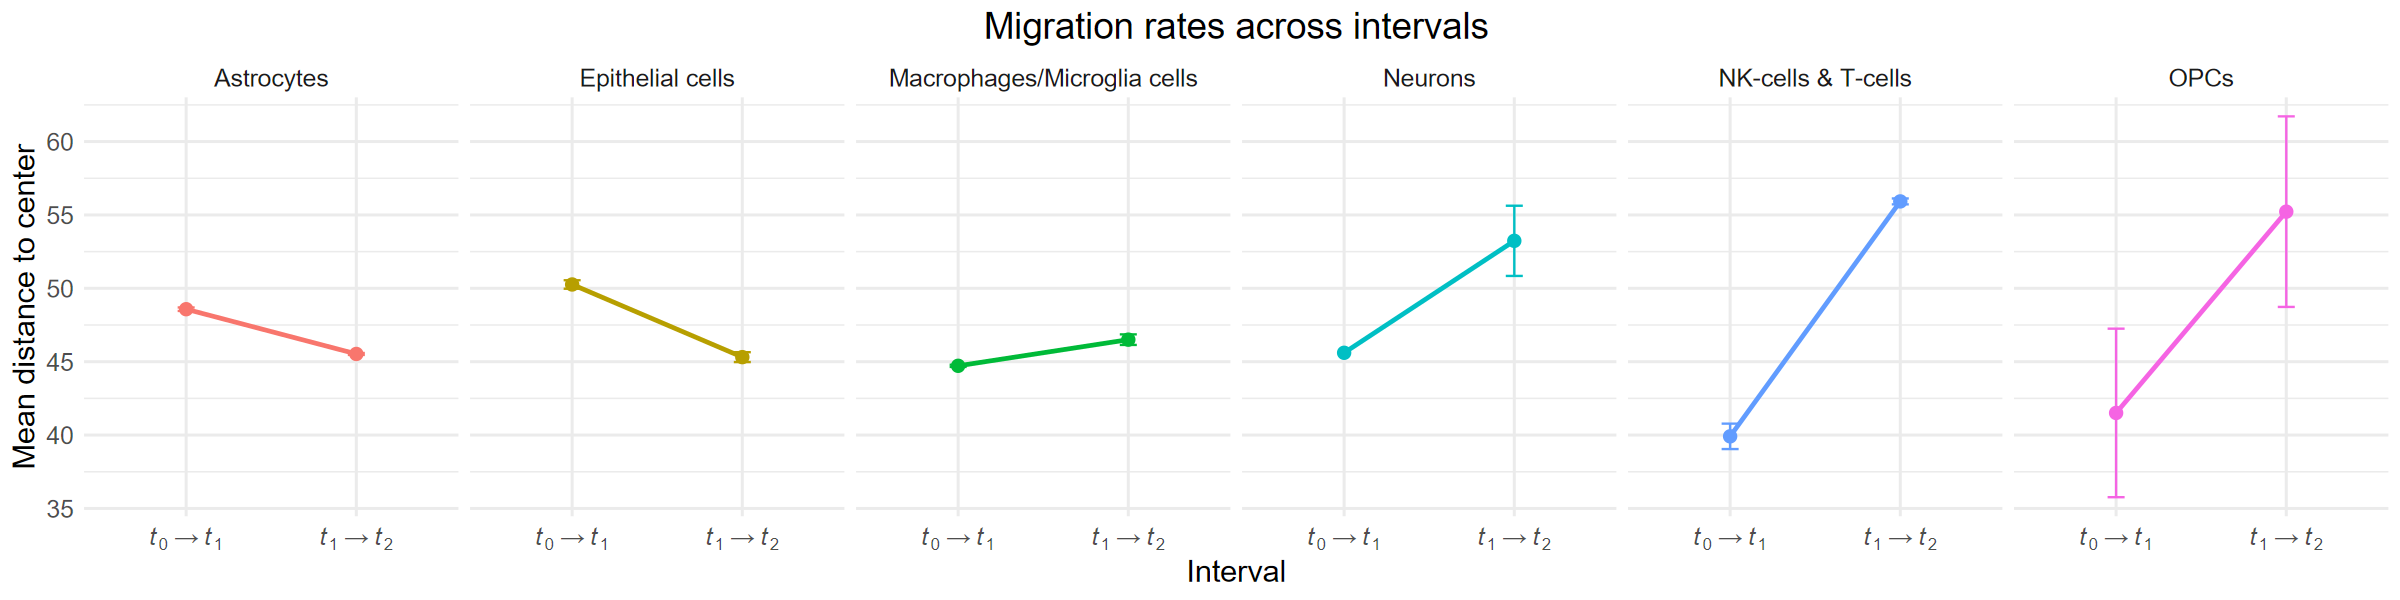

In [15]:
# Summarize per cell type × interval
mig_plot_summary <- mig_df %>% group_by(baseline_ct, interval) %>% summarise(mean_dist = mean(dist, na.rm = TRUE), N = n(),
                                                                             se_dist = sd(dist, na.rm = TRUE)/sqrt(N), .groups = "drop")

# Prepare annotation (ANOVA p-values)
pvals <- mig_stats %>% mutate(y.position = max(mig_plot_summary$mean_dist) + 1, 
                              group1 = "TF0→TF1", group2 = "TF1→TF2", label = paste0("p=", signif(p_adj, 3)))

options(repr.plot.height = 5, repr.plot.width = 20)
p <- ggplot(mig_plot_summary, aes(x = interval, y = mean_dist, group = baseline_ct, color = baseline_ct)) +
            geom_point(size = 3) + geom_line(size = 1) + geom_errorbar(aes(ymin = mean_dist - se_dist, ymax = mean_dist + se_dist), width = 0.1) +
            facet_wrap(~ baseline_ct, nrow = 1) + theme_minimal(base_size = 14) + labs(title = "Migration rates across intervals",
                                                                                       y = "Mean distance to center", x = "Interval") +
                                                                                       scale_x_discrete(labels = c("TF0→TF1" = expression(italic(t)[0] %->% italic(t)[1]),
                                                                                                                   "TF1→TF2" = expression(italic(t)[1] %->% italic(t)[2]))) +
                                                                                       theme(plot.title = element_text(hjust = 0.5),
                                                                                             text = element_text(size = 18),
                                                                                             legend.position = "none")

# Add p-value annotation
#if (nrow(pvals) > 0) {
#    p <- p + stat_pvalue_manual(pvals, label = "label", tip.length = 0.01, hide.ns = TRUE)
#}

p
ggsave("../Results - GBM/4_modelling/mig_plot.tiff", p, width = 15, height = 5, dpi = 350, compression = "lzw")

In [14]:
# Prepare differentiation sentences
diff_sentences <- c()
for (ct in unique(diff_stats$baseline_ct)) {
  
  row_stat <- diff_stats[diff_stats$baseline_ct == ct & diff_stats$method == "Fisher", ]
  
  if (nrow(row_stat) == 0 || is.na(row_stat$p_value)) {
    sentence <- paste0("Differentiation frequency of ", ct, " could not be tested due to insufficient data.")
  } else {
    prop_start <- round(diff_sum$prop_changed[diff_sum$baseline_ct == ct & diff_sum$interval == "TF0→TF1"]*100,1)
    prop_end   <- round(diff_sum$prop_changed[diff_sum$baseline_ct == ct & diff_sum$interval == "TF1→TF2"]*100,1)
    p_adj_val  <- signif(row_stat$p_adj,3)
    sentence <- paste0("Differentiation frequency of ", ct,
                       " changed from ", prop_start, "% in TF0→TF1 to ", prop_end, "% in TF1→TF2 ",
                       "(Fisher’s exact test, p_adj = ", p_adj_val, ").")
  }
  
  diff_sentences <- c(diff_sentences, sentence)
}
diff_sentences

# Prepare migration sentences
mig_sentences <- c()
for (ct in unique(mig_stats$baseline_ct)) {
  
  row_stat <- mig_stats[mig_stats$baseline_ct == ct, ]
  mean_start <- round(mig_sum$mean_dist[mig_sum$baseline_ct == ct & mig_sum$interval == "TF0→TF1"],2)
  mean_end   <- round(mig_sum$mean_dist[mig_sum$baseline_ct == ct & mig_sum$interval == "TF1→TF2"],2)
  p_adj_val  <- signif(row_stat$p_adj,3)
  
  sentence <- paste0("Migration rate of ", ct, " changed from ", mean_start, " to ", mean_end,
                     " (one-way ANOVA, p_adj = ", p_adj_val, ").")
  
  mig_sentences <- c(mig_sentences, sentence)
}
mig_sentences

[1] "Differentiation frequency of Astrocytes changed from 8.4% in TF0→TF1 to 36.7% in TF1→TF2 (Fisher’s exact test, p_adj = 0)."                
[2] "Differentiation frequency of Epithelial cells changed from 60.8% in TF0→TF1 to 23.5% in TF1→TF2 (Fisher’s exact test, p_adj = 6.87e-146)." 
[3] "Differentiation frequency of Macrophages/Microglia cells changed from 96.1% in TF0→TF1 to 57% in TF1→TF2 (Fisher’s exact test, p_adj = 0)."
[4] "Differentiation frequency of Neurons changed from 0% in TF0→TF1 to 35.7% in TF1→TF2 (Fisher’s exact test, p_adj = 1)."                     
[5] "Differentiation frequency of NK-cells & T-cells changed from 96.5% in TF0→TF1 to 97.2% in TF1→TF2 (Fisher’s exact test, p_adj = 0.651)."   
[6] "Differentiation frequency of OPCs could not be tested due to insufficient data."

[1] "Migration rate of Astrocytes changed from 48.58 to 45.53 (one-way ANOVA, p_adj = 8.72e-105)."               
[2] "Migration rate of Epithelial cells changed from 50.26 to 45.31 (one-way ANOVA, p_adj = 1.5e-28)."           
[3] "Migration rate of Macrophages/Microglia cells changed from 44.72 to 46.5 (one-way ANOVA, p_adj = 2.41e-06)."
[4] "Migration rate of NK-cells & T-cells changed from 39.91 to 55.92 (one-way ANOVA, p_adj = 3.32e-138)."       
[5] "Migration rate of Neurons changed from 45.61 to 53.24 (one-way ANOVA, p_adj = 0.425)."                      
[6] "Migration rate of OPCs changed from 41.51 to 55.22 (one-way ANOVA, p_adj = 0.266)."

###### **Cell migration modeling**

In [ ]:
suppressPackageStartupMessages({
    library(gganimate)
    theme_set(theme_bw())
})

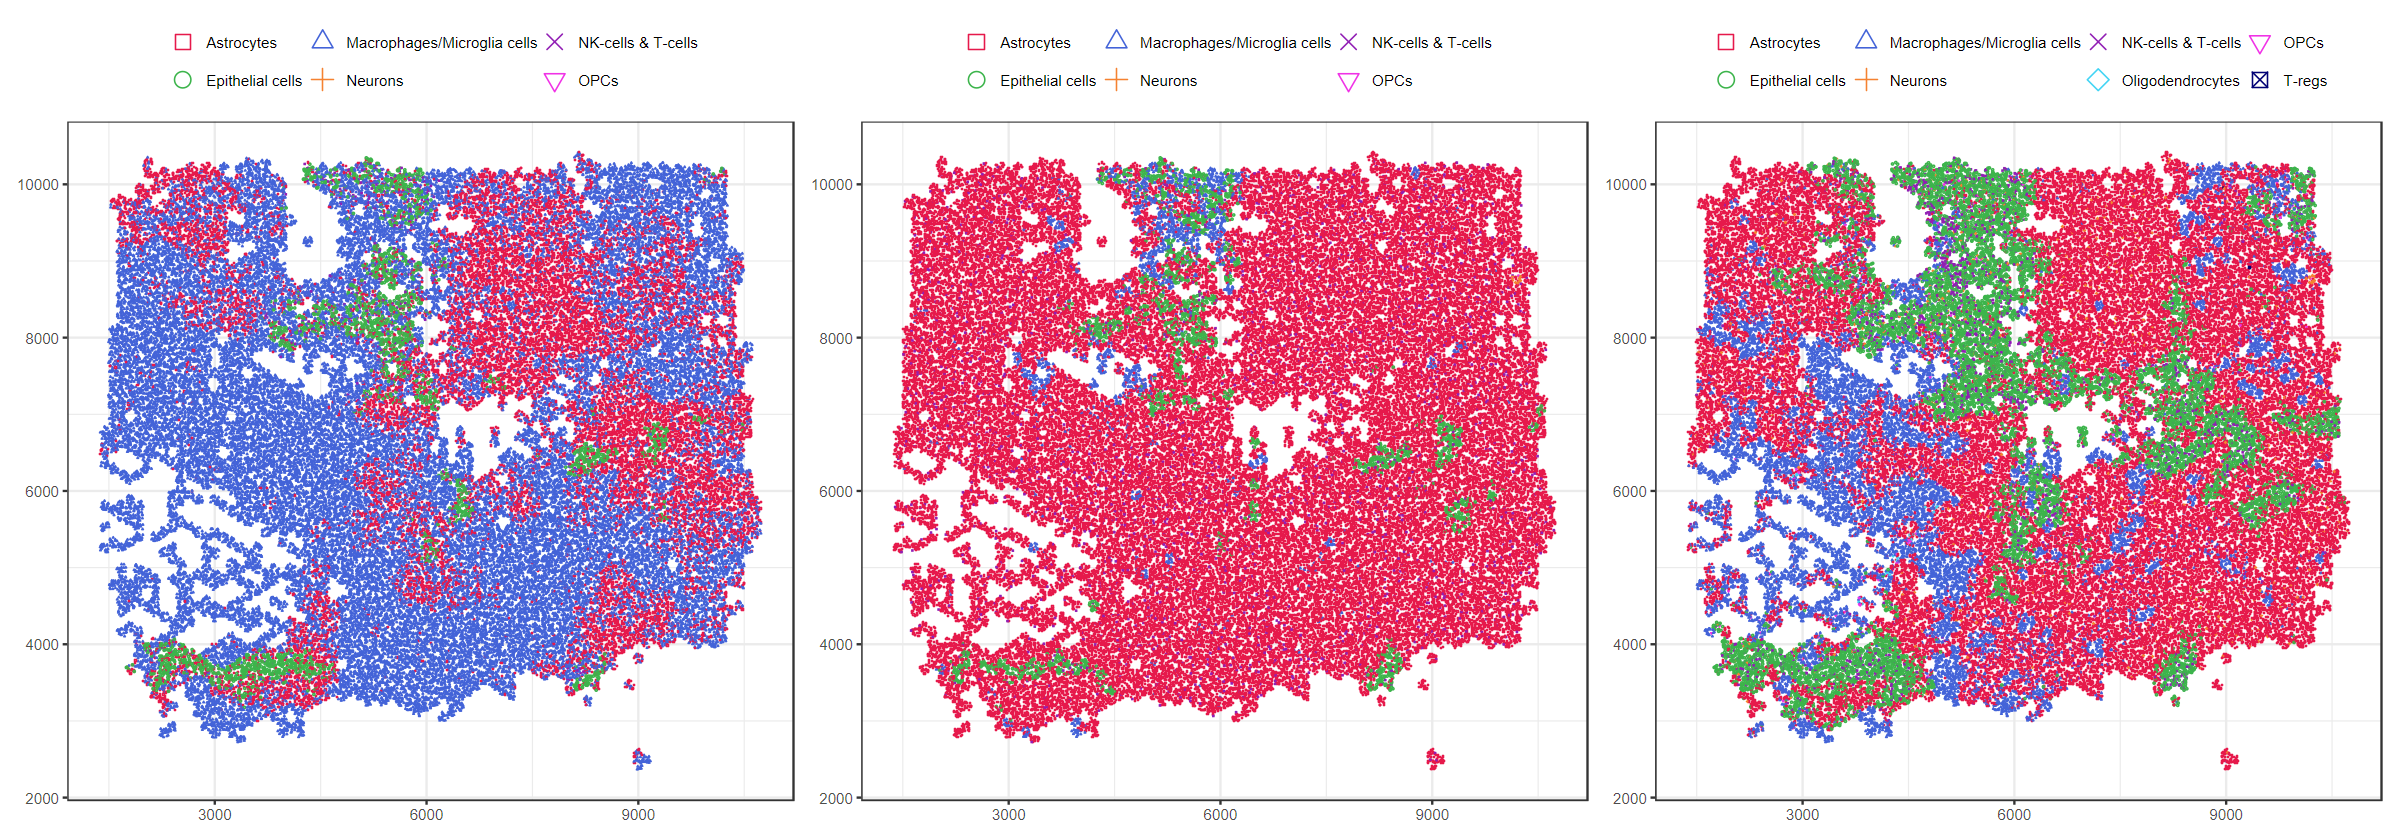

In [3]:
CellLoc <- read.csv(paste0('../Results - GBM/4_modelling/', smpl_info$patient, '_CellLoc.csv'))

#CellLoc$matching <- (CellLoc$TF0_ct != CellLoc$TF1_ct) & (CellLoc$TF1_ct != CellLoc$TF2_ct) & (CellLoc$TF2_ct != CellLoc$TF0_ct)
#CellLoc <- CellLoc[which(CellLoc$matching == TRUE), ]

t0 <- strsplit(sort(unique(CellLoc$TF0_ct), decreasing = FALSE), split = "[.]")
t1 <- strsplit(sort(unique(CellLoc$TF1_ct), decreasing = FALSE), split = "[.]")
t2 <- strsplit(sort(unique(CellLoc$TF2_ct), decreasing = FALSE), split = "[.]")
idx <- which.max(lengths(list(t0, t1, t2)))
colors <- c('#e6194B', '#3cb44b', '#4363d8', '#f58231', '#911eb4', '#42d4f4', '#f032e6', '#000075', '#9A6324', '#800000', '#000000', '#469990')
shapes <- c('square open', 'circle open', 'triangle open', 'plus', 'cross', 'diamond open', 'triangle down open', 'square cross', 'asterisk', 'diamond plus', 'circle plus')
pointColors <- setNames(colors, list(t0, t1, t2)[[idx]])
pointShapes <- setNames(shapes, list(t0, t1, t2)[[idx]])

p1 <- ggplot() + geom_point(CellLoc, mapping=aes(x, y, shape=TF0_ct, color=TF0_ct), size=.001) + theme_bw() + theme(legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)
p2 <- ggplot() + geom_point(CellLoc, mapping=aes(x, y, shape=TF1_ct, color=TF1_ct), size=.001) + theme_bw() + theme(legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)
p3 <- ggplot() + geom_point(CellLoc, mapping=aes(x, y, shape=TF2_ct, color=TF2_ct), size=.001) + theme_bw() + theme(legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)

options(repr.plot.height = 7, repr.plot.width = 20)
p1 + p2 + p3 + plot_layout(ncol = 3)

In [4]:
ctTF0 <- c(sort(unique(CellLoc$TF0_ct), decreasing = FALSE))
ctTF1 <- c(sort(unique(CellLoc$TF1_ct), decreasing = FALSE))
ctTF2 <- c(sort(unique(CellLoc$TF2_ct), decreasing = FALSE))

length(ctTF0) <- length(ctTF1) <- length(ctTF2) <- max(length(ctTF0), length(ctTF1), length(ctTF2))                      
ctList <- as.data.frame(cbind(ctTF0, ctTF1, ctTF2))
colnames(ctList) <- c('Celltypes of TF0', 'Celltypes of TF1', 'Celltypes of TF2')
ctList[is.na(ctList)] <- ""
ctList

Celltypes of TF0,Celltypes of TF1,Celltypes of TF2
<chr>,<chr>,<chr>
Astrocytes,Astrocytes,Astrocytes
Epithelial cells,Epithelial cells,Epithelial cells
Macrophages/Microglia cells,Macrophages/Microglia cells,Macrophages/Microglia cells
Neurons,Neurons,Neurons
NK-cells & T-cells,NK-cells & T-cells,NK-cells & T-cells
OPCs,OPCs,Oligodendrocytes
,,OPCs
,,T-regs


###### *Cell differentiation*

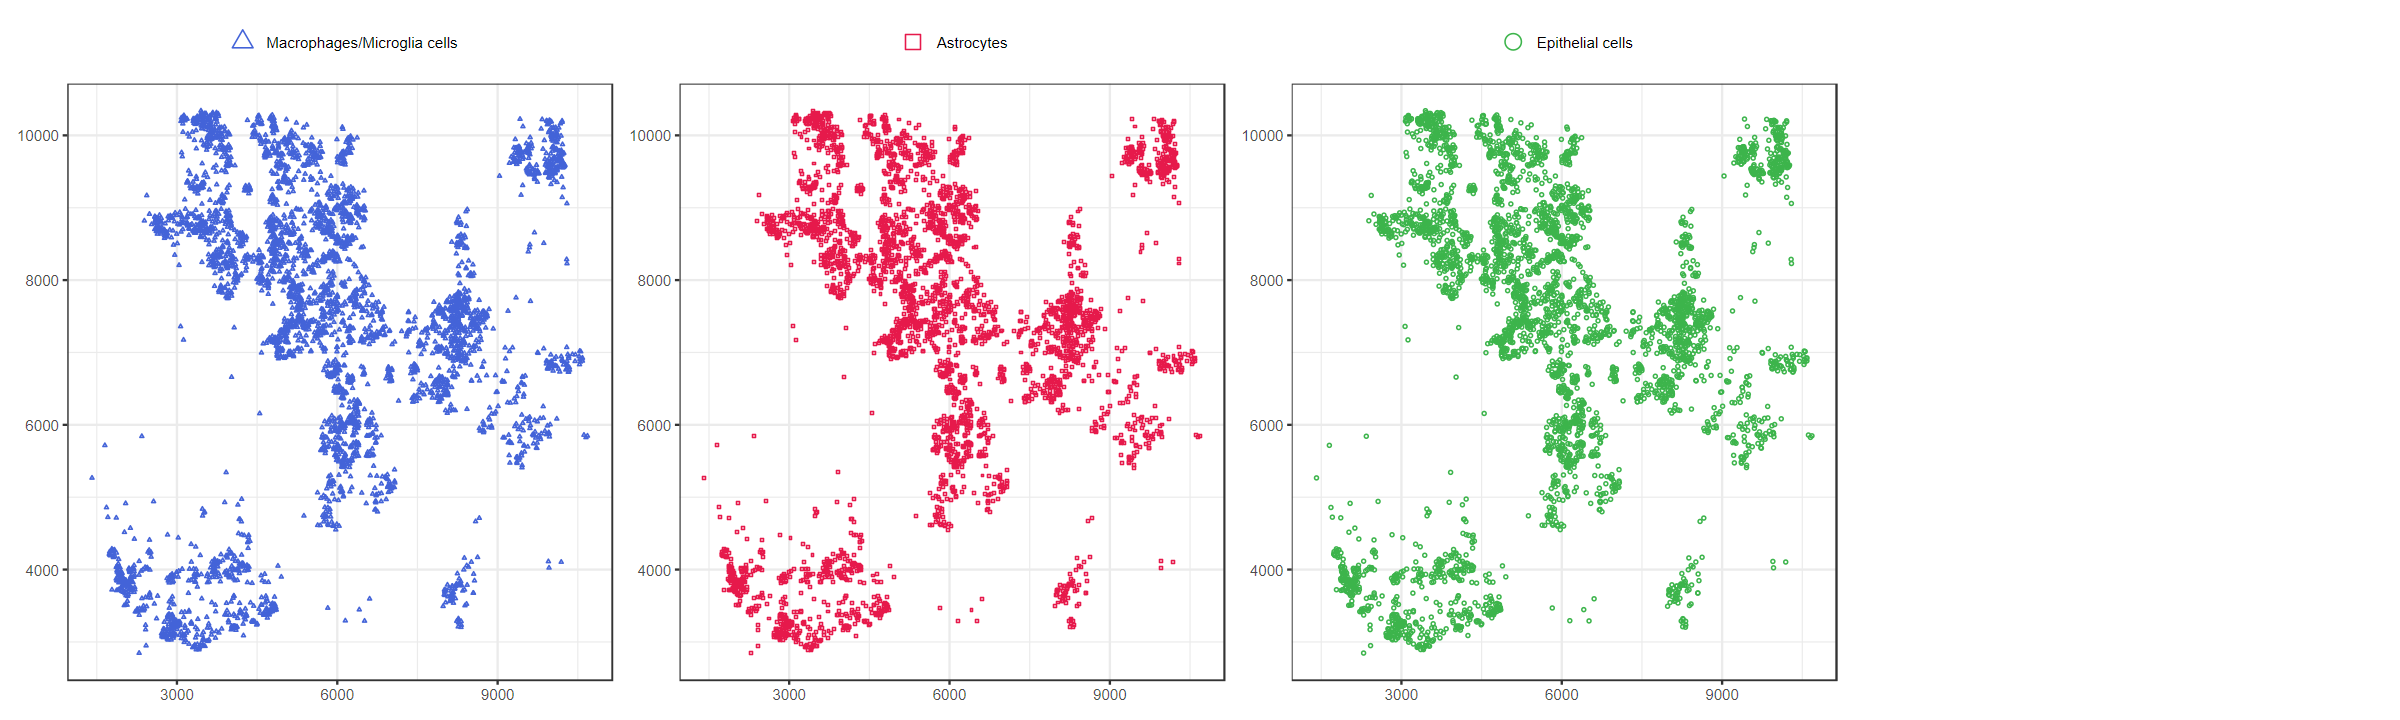

In [5]:
DF <- filter(CellLoc, TF0_ct %in% c('Macrophages/Microglia cells') & TF1_ct %in% c('Astrocytes') & TF2_ct %in% c('Epithelial cells'))
if (nrow(DF) != 0){
    p1 <- ggplot(DF, aes(x, y, shape=TF0_ct, color=TF0_ct)) + geom_point(size=.5) + theme_bw() + theme(legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)
    p2 <- ggplot(DF, aes(x, y, shape=TF1_ct, color=TF1_ct)) + geom_point(size=.5) + theme_bw() + theme(legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)
    p3 <- ggplot(DF, aes(x, y, shape=TF2_ct, color=TF2_ct)) + geom_point(size=.5) + theme_bw() + theme(legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)

    tmp0 = select(DF, c(x, y, centerSPOT, centerx, centery, TF0, TF0_ct))
    tmp1 = select(DF, c(x, y, centerSPOT, centerx, centery, TF1, TF1_ct))
    tmp2 = select(DF, c(x, y, centerSPOT, centerx, centery, TF2, TF2_ct))
    colnames(tmp2)=colnames(tmp1)=colnames(tmp0)
    CellMig = rbind(tmp0, tmp1, tmp2)
    row.names(CellMig) <- seq.int(nrow(CellMig))
    colnames(CellMig) <- c('x', 'y', 'centerSPOT', 'centerx', 'centery', 'TF', 'TF_ct')
    #pd <- ggplot() + geom_point(CellMig, mapping = aes(x, y, shape=TF_ct, color=TF_ct), size=.5) + theme_bw() + labs(caption = paste0("Number of cells in all time frames: ", nrow(DF))) + theme(plot.caption = element_text(size = 14), legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)
}
    options(repr.plot.height = 6, repr.plot.width = 20)
    #pdf(file = paste0("../Results - GBM/4_modelling/", smpl_info$patient, "_CellDiff.pdf"), height = 6, width = 20, useDingbats=FALSE)
    #p1 + p2 + p3 + pd + plot_layout(ncol = 4)
    p1 + p2 + p3 + plot_layout(ncol = 4)
    #dev.off()

In [ ]:
library(plotly)
library(webshot2)

all_types <- sort(unique(c(CellLoc$TF0_ct, CellLoc$TF1_ct, CellLoc$TF2_ct)))
pointColors <- setNames(colors[1:length(all_types)], all_types)
pointShapes <- setNames(shapes[1:length(all_types)], all_types)

DF <- filter(CellLoc, TF0_ct %in% c('Macrophages/Microglia cells') & TF1_ct %in% c('Astrocytes') & TF2_ct %in% c('Epithelial cells'))

if (nrow(DF) != 0){
    tmp0 <- DF %>% select(x, y, TF0, TF0_ct) %>% mutate(z = 0, TF_ct = TF0_ct)
    tmp1 <- DF %>% select(x, y, TF1, TF1_ct) %>% mutate(z = 1, TF_ct = TF1_ct)
    tmp2 <- DF %>% select(x, y, TF2, TF2_ct) %>% mutate(z = 2, TF_ct = TF2_ct)

    CellMig <- bind_rows(tmp0, tmp1, tmp2)

    # factor با exact levels = نام‌های pointColors
    CellMig$TF_ct <- factor(CellMig$TF_ct, levels = names(pointColors))

    fig <- plot_ly(
        CellMig, x = ~x, y = ~y, z = ~z,
        color = ~TF_ct, colors = pointColors,
        symbol = ~TF_ct, symbols = pointShapes,
        type = 'scatter3d', mode = 'markers',
        marker = list(size = 2)
    )

    fig <- fig %>% layout(
        scene = list(
            xaxis = list(title = "", showticklabels = FALSE, showgrid = TRUE, zeroline = FALSE),
            yaxis = list(title = "", showticklabels = FALSE, showgrid = TRUE, zeroline = FALSE),
            zaxis = list(
                title = "",
                tickmode = "array",
                tickvals = c(0, 1, 2),
                ticktext = c("Time t=0", "Time t=1", "Time t=2")
            )
        ),
        legend = list(title = list(text = ""))
    )
    fig
}

webshot2::webshot(url = "./CellMigration3D.html", file = "./CellMigration3D.png", vwidth = 3000, vheight = 3000, zoom = 4, delay = 2)

###### *Cell Migration*

In [16]:
DF0 <- filter(CellLoc, TF0_ct %in% c('Epithelial cells'))
DF1 <- filter(CellLoc, TF1_ct %in% c('Epithelial cells'))
DF2 <- filter(CellLoc, TF2_ct %in% c('Epithelial cells'))
if (nrow(DF0) != 0 & nrow(DF1) != 0 & nrow(DF2) != 0){
    p1 <- ggplot(DF0, aes(x, y, shape=TF0_ct, color=TF0_ct)) + geom_point(size=1) + theme_bw() + labs(caption = paste0("Number of cells: ", nrow(DF0))) + theme(plot.caption = element_text(size = 12), legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)
    p2 <- ggplot(DF1, aes(x, y, shape=TF1_ct, color=TF1_ct)) + geom_point(size=1) + theme_bw() + labs(caption = paste0("Number of cells: ", nrow(DF1))) + theme(plot.caption = element_text(size = 12), legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)
    p3 <- ggplot(DF2, aes(x, y, shape=TF2_ct, color=TF2_ct)) + geom_point(size=1) + theme_bw() + labs(caption = paste0("Number of cells: ", nrow(DF2))) + theme(plot.caption = element_text(size = 12), legend.position="top", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + guides(shape = guide_legend(override.aes = list(size = 4))) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)

    tmp0 = select(DF0, c(x, y, centerSPOT, centerx, centery, TF0, TF0_ct))
    tmp1 = select(DF1, c(x, y, centerSPOT, centerx, centery, TF1, TF1_ct))
    tmp2 = select(DF2, c(x, y, centerSPOT, centerx, centery, TF2, TF2_ct))
    colnames(tmp2)=colnames(tmp1)=colnames(tmp0)
    CellMig = rbind(tmp0, tmp1, tmp2)
    row.names(CellMig) <- seq.int(nrow(CellMig))
    colnames(CellMig) <- c('x', 'y', 'centerSPOT', 'centerx', 'centery', 'TF', 'TF_ct')
    ps <- ggplot() + geom_point(CellMig, mapping = aes(x, y, shape=TF_ct, color=TF_ct), size=1) + theme_bw() + labs(caption = paste0('All time frames of ', DF0$TF0_ct[[1]])) + theme(plot.caption = element_text(size = 12), legend.position="none", legend.title=element_blank(), axis.title.x = element_blank(), axis.title.y = element_blank()) + scale_colour_manual(values =  pointColors) + scale_shape_manual(values = pointShapes)
}
    options(repr.plot.height = 7, repr.plot.width = 20)
    pdf(file = paste0("../Results - GBM/4_modelling/", smpl_info$patient, "_CellMig.pdf"), height = 6, width = 20, useDingbats=FALSE)
    p1 + p2 + p3 + plot_layout(ncol = 3)
    dev.off()

pdf 
  2

In [17]:
animp <- ps + transition_time(CellMig$TF) + ease_aes('linear') + labs(title = "Time frame: {frame_time}") + shadow_wake(wake_length = 1) 
animate(animp, nframes = max(CellMig$TF) - min(CellMig$TF) + 1, fps = 1, duration = 3, 
        renderer = gifski_renderer(paste0('../Results - GBM/4_modelling/', smpl_info$patient, '.gif')))


Rendering [==============>-----------------------------] at 1.6 fps ~ eta:  1s

Rendering [============================>---------------] at 1.5 fps ~ eta:  1s

Rendering [============================================] at 1.2 fps ~ eta:  0s
                                                                              



###### *ShinyApp*

In [6]:
suppressPackageStartupMessages({
    library(shiny)
    library(shinyWidgets)
    library(tidyverse)
    library(shinydashboard)
    library(DT)
})

In [ ]:
ui <- fluidPage(
    tags$head(
        tags$style(HTML(".header 
                        {background-image: url('https://raw.githubusercontent.com/pursalimm/tcm/e8c85731660156303692990ea5854df6d823a087/tcm-header.png?token=GHSAT0AAAAAACXOVZ5AVRO2LQIWKTF234GUZXENTFA');
                        background-size: cover;
                        padding: 40px;
                        color: black;
                        text-align: center;
                        position: relative;
                        font-size: 30px;}
                        .close-button {position:absolute; bottom:10px; right:10px; color:red;}"))
    ),
    div(class = "header", "Tumor Cell Migration Modeling", actionButton("close", "Exit App", class = "close-button", onclick = "window.close();")),
    
    tabsetPanel(
        tabPanel("Uploading Dataset", 
                 fileInput("file", "Choose CSV File", accept = ".csv"), 
                 radioButtons("disp", "Display", choices = c(Head = "head", Tail = "tail", All = "all")),
                 DTOutput("table")
                 ),
        tabPanel("Choosing Celltypes",
                 uiOutput("dropdown_ui")
                 ),
        tabPanel("Help", h3("Help content goes here")
                ),
        tabPanel("About", h3("Citation:\nMahdi Pursalim,  Kaveh Kavousi,  Parisa Shooshtari \n Contact: kkavousi@ut.ac.ir")
                ),
        )
)

server <- function(input, output, session) {
    options(shiny.maxRequestSize = 100 * 1024^2)
    data <- reactive({
        req(input$file)
        df <- read.csv(input$file$datapath)
        df
    })

    output$table <- renderDT({
        req(data())
        df <- data()
        if (input$disp == "head") {
            datatable(head(df))
        } else if (input$disp == "tail") {
            datatable(tail(df))
        } else {
            datatable(df)
        }
    })

    output$dropdown_ui <- renderUI({
        req(data())
        df <- data()
        special_cols <- grep("special", names(df), value = TRUE)
        selectInput("dropdown", "Choose Columns", choices = special_cols, multiple = TRUE)
    })

    observeEvent(input$close, {
        stopApp();
    })
}

shinyApp(ui, server)


Listening on http://127.0.0.1:7889



In [ ]:
1- header with a background image.
2- four tabs that includes Uploading dataset, Choosing celltypes, help, about, and a button to close the app placed in the header.
3- Uploading dataset uses for csv files greater than 5 MB, display data in the form of head, tail, and all, and also show datatable with search option.
4- Choosing celltypes tab that dynamically creates dropdown based on  a number of special columns in the uploaded csv file.
